# 03. 유동인구 EDA (SK 유동인구 + 지하철)

## 이 노트북이 하는 일
카드 매출이 줄었을 때 **사람이 안 나온 건지, 나왔는데 덜 쓴 건지** 가려내려면 사람 흐름(유동) 자료가 필요한다.
이 노트북은 두 가지 유동 자료를 살펴본다.
- **SK 유동인구**: 50m 격자별 **월 단위** 자료. 날짜별로는 못 보지만, 사람이 어디에 언제(시간대, 요일) 모이는지 **공간 구조**를 알려준다.
- **지하철 승하차**: 역별 **일 단위** 자료. 날씨가 나쁜 날 사람 흐름이 줄었는지 볼 수 있는 유일한 일별 유동 지표이다.

마지막에 지하철 일별 합계를 저장해서 05번, 07번이 카드 매출과 나란히 놓고 쓰게 한다.

## 답해야 할 질문
1. SK 유동인구의 좌표(x, y)는 정말 EPSG:5179(UTM-K)인가? 격자를 행정동에 제대로 붙일 수 있는가?
2. 01번이 남긴 문제 두 가지(주말만 0인 격자, 파일마다 다른 격자 수)는 분석에 문제가 되는가?
3. 강남과 춘천은 사람이 모이는 시간대, 요일, 장소가 어떻게 다른가? 카드 매출 패턴과 같은가?
4. 지하철 역 목록은 적절한가? 지하철 이용은 요일, 연휴, 작년과 비교해 어떻게 움직이는가?
5. 지하철 이용과 카드 매출은 날마다 같이 움직이는가? (탐색 Q6-b "유동도 줄었나, 매출만 줄었나"의 준비)

## 입력과 출력
| 입력 (`notebooks/preprocessed/`) | 출력 |
|---|---|
| `flow_age.parquet`, `flow_time.parquet`, `flow_wkdy.parquet`, `dong_boundary.geojson`, `dong_codes.csv`, `subway.parquet`, `card1.parquet`, `calendar.parquet` | 그래프 (노트북 안), `subway_region_daily.parquet` (10장) |

01번 노트북을 먼저 실행해서 `preprocessed/` 폴더에 파일이 있어야 한다. 권장 순서는 01 -> 02 -> 03 -> 04 -> 07 -> 05 -> 06 이다. (02번은 이 노트북에서 카드 결과를 비교할 때 참고만 한다)


## 0. 준비

### 0-1. 라이브러리 불러오기와 그래프 기본 설정

In [1]:
# 라이브러리 불러오기와 그래프 기본 설정
import warnings
from pathlib import Path          # 파일 경로 다루기 (윈도우/맥 상관없이 동작)
from IPython.display import display   # 표를 칸이 나뉜 표로 보여줌 (print(표)는 글자로만 나와서 보기 불편함)

# geopandas를 불러올 때 뜨는 GDAL 경고는 동작에 영향이 없어서 숨길다. (import보다 먼저 설정해야 함)
warnings.filterwarnings('ignore', message='.*GDAL.*')

import numpy as np                # 숫자 계산
import pandas as pd               # 표(DataFrame) 다루기
import matplotlib.pyplot as plt   # 그래프 그리기
import seaborn as sns             # 통계 그래프를 쉽게 그려줌
import geopandas as gpd           # 지도(도형) 데이터를 다루는 pandas. 행정동 경계와 격자 좌표를 겹칠 때 씀

# ── 한글 폰트 설정 (안 하면 그래프의 한글이 네모로 깨짐) ──
plt.rc('font', family='Malgun Gothic')     # 윈도우 기본 한글 폰트
plt.rc('axes', unicode_minus=False)        # 한글 폰트를 쓰면 음수 부호(-)가 깨지는 것 방지

# ── 그래프 기본 크기와 선명도 ──
plt.rc('figure', figsize=(12, 4), dpi=110)  # 가로 12, 세로 4 (인치), dpi = 선명도

# ── 지역 색: 모든 그래프에서 같은 지역은 같은 색 (02번과 같음) ──
REGIONS = ['강남', '춘천']
REGION_COLOR = {'강남': '#1f77b4', '춘천': '#ff7f0e'}   # 파랑, 주황

# 로그 축 눈금을 10⁻¹ 같은 수식 대신 보통 숫자(0.1, 1, 10)로 표시 (한글 폰트에서 음수 기호가 깨지는 것 방지)
LOG_FMT = plt.FuncFormatter(lambda v, _: f'{v:g}')

# ── 표 출력 설정 ──
pd.set_option('display.float_format', '{:,.2f}'.format)   # 숫자에 쉼표, 소수 둘째 자리까지
pd.set_option('display.max_columns', 60)                  # 열이 많아도 중간을 ... 으로 생략하지 않음

print('pandas', pd.__version__, '| geopandas', gpd.__version__)

pandas 2.2.3 | geopandas 1.1.3


### 0-2. 경로 설정과 데이터 불러오기

In [2]:
# 01번 노트북과 같은 방식: 'dataset 폴더가 있는 곳'이 나올 때까지 상위 폴더로 올라가며 프로젝트 맨 위 폴더를 찾는다.
ROOT = Path.cwd()
while not (ROOT / 'dataset').exists():
    if ROOT.parent == ROOT:    # 드라이브 맨 위까지 올라갔는데도 없으면 멈춤
        raise FileNotFoundError('dataset 폴더를 찾을 수 없다. 노트북 위치를 확인한다.')
    ROOT = ROOT.parent
OUT = ROOT / 'notebooks' / 'preprocessed'     # 01번이 정리한 파일이 있는 폴더

flow_age = pd.read_parquet(OUT / 'flow_age.parquet')      # 격자별 성별 × 연령 유동인구
flow_time = pd.read_parquet(OUT / 'flow_time.parquet')    # 격자별 0~23시 유동인구
flow_wkdy = pd.read_parquet(OUT / 'flow_wkdy.parquet')    # 격자별 월~일 유동인구
dong = gpd.read_file(OUT / 'dong_boundary.geojson')       # 행정동 경계 (지도)
dong_codes = pd.read_csv(OUT / 'dong_codes.csv', dtype=str)   # 코드는 글자로 읽기 (앞자리 0 보호)
subway = pd.read_parquet(OUT / 'subway.parquet')          # 지하철 날짜 × 노선 × 역별 승하차
card1 = pd.read_parquet(OUT / 'card1.parquet')            # 카드 데이터1 (10장 상관 분석 등에 씀)
calendar = pd.read_parquet(OUT / 'calendar.parquet')      # 달력 (요일, 공휴일, 추석)

# 제대로 읽혔는지 크기(행 × 열) 확인
tables = {'flow_age': flow_age, 'flow_time': flow_time, 'flow_wkdy': flow_wkdy, 'dong': dong,
          'dong_codes': dong_codes, 'subway': subway, 'card1': card1, 'calendar': calendar}
for name, df in tables.items():
    print(f'{name:11s} {df.shape[0]:>10,}행 × {df.shape[1]:>2}열')
print('dong 좌표계:', dong.crs)      # EPSG:4326 = 위도, 경도

flow_age       595,915행 × 18열
flow_time      570,475행 × 30열
flow_wkdy      720,165행 × 13열
dong                47행 ×  7열
dong_codes          47행 ×  6열
subway         822,891행 ×  6열
card1        1,044,710행 × 11열
calendar           184행 ×  9열
dong 좌표계: EPSG:4326


### 0-3. 값 열 목록과 기본 표 만들기

In [3]:
# 유동인구 세 파일의 "값 열" 목록. 합계를 낼 때 이 목록을 쓴다.
AGE_COLS = [c for c in flow_age.columns if 'FLOW_POP_CNT' in c]           # 남녀 × 연령 12개
TIME_COLS = [c for c in flow_time.columns if c.startswith('TMST_')]       # 0~23시 24개
WKDY_COLS = [c for c in flow_wkdy.columns if c.startswith('FLOW_POP_CNT_')]   # 월~일 7개 (MON ... SUN 순서)
DOW = list('월화수목금토일')                                               # 요일 이름 (0=월 ... 6=일)
print(len(AGE_COLS), len(TIME_COLS), len(WKDY_COLS), WKDY_COLS)

# 격자 한 행의 합계 = 그 격자의 하루 유동인구
flow_age['total'] = flow_age[AGE_COLS].sum(axis=1)       # axis=1: 한 행 안에서 가로로 더하기
flow_time['total'] = flow_time[TIME_COLS].sum(axis=1)
flow_wkdy['total'] = flow_wkdy[WKDY_COLS].sum(axis=1)

# 카드 일매출 (02번과 같은 정의): 분석 대상 업종 + 개인 결제
base1 = card1[card1['is_target'] & card1['sex'].ne('법인')].copy()   # .ne('법인') = "법인이 아닌가?"
sales = base1.groupby(['date', 'region'])['amount'].sum().unstack('region') / 1e8   # unstack: region 값을 열로 펼치기 -> 억 원
print('sales', sales.shape)
display(sales.mean().round(1).to_frame('일평균 매출(억 원)'))

# 달력을 날짜로 찾기 쉽게 date를 행 이름(index)으로
cal = calendar.set_index('date')


def shade_days(ax):
    """그래프(ax)에 쉬는 날은 회색, 추석 연휴는 주황 배경을 칠한다. (2025 하반기 그래프용, 02번과 같은 함수)"""
    half = pd.Timedelta(hours=12)                      # 하루 칸의 절반. 날짜 앞뒤로 12시간씩 칠해서 하루 폭이 되게
    for d in cal.index[cal['is_offday']]:
        ax.axvspan(d - half, d + half, color='lightgray', alpha=0.5, lw=0)   # axvspan: x축 구간에 세로 띠 칠하기
    ch = cal.index[cal['is_chuseok_break']]
    ax.axvspan(ch.min() - half, ch.max() + half, color='orange', alpha=0.25, lw=0)

12 24 7 ['FLOW_POP_CNT_MON', 'FLOW_POP_CNT_TUS', 'FLOW_POP_CNT_WED', 'FLOW_POP_CNT_THU', 'FLOW_POP_CNT_FRI', 'FLOW_POP_CNT_SAT', 'FLOW_POP_CNT_SUN']


sales (184, 2)


,일평균 매출(억 원)
region,
강남,526.20
춘천,79.70


## 1. SK 유동인구 데이터 이해하기
분석에 들어가기 전에 **한 행이 무엇을 뜻하는지**, 세 파일(성별연령, 시간대, 요일)의 값이 같은 양인지 확인한다.
여기서 "격자"를 잘못 이해하면 뒤의 모든 집계가 틀어진다.

### 1-1. 한 행은 무엇인가 (block_cd와 격자)

In [4]:
# block_cd가 정말 50m 격자 코드인지, 아니면 더 큰 구역 코드인지 확인한다.
n_block = flow_age['block_cd'].nunique()                       # nunique: 서로 다른 값의 개수
n_cell = len(flow_age.drop_duplicates(['x', 'y']))             # (x, y) 좌표 조합의 개수
print(f'block_cd 종류: {n_block:,}개 / (x, y) 좌표 조합: {n_cell:,}개')
display(flow_age.groupby('region')['block_cd'].nunique().to_frame('block_cd 수'))

# 한 달(2025-10)만 보고, block_cd 하나에 (x, y)가 몇 개 들어 있는지
per_block = flow_age[flow_age['ym'].eq('202510')].groupby('block_cd').size()
display(per_block.describe().round(1).to_frame('block_cd 하나에 든 격자 수'))

# x 좌표를 정렬해서 이웃한 값의 차이 -> 격자 간격
gaps = pd.Series(np.diff(np.sort(flow_age['x'].unique()))).round(2)   # np.diff: 바로 옆 값과의 차이
display(gaps.value_counts().head(3).to_frame('횟수').rename_axis('x 간격(m)'))

# (x, y) 하나가 block_cd 여러 개에 걸치는가? 1이면 "격자 하나는 block_cd 하나에만 속함"
print('(x, y) 하나에 붙은 block_cd 최대 개수:', flow_age.groupby(['x', 'y'])['block_cd'].nunique().max())

block_cd 종류: 2,776개 / (x, y) 좌표 조합: 111,290개


,block_cd 수
region,
강남,2030
춘천,746


,block_cd 하나에 든 격자 수
count,"2,776.00"
mean,36.30
std,207.70
min,1.00
25%,2.00
50%,4.00
75%,7.00
max,"3,739.00"


,횟수
x 간격(m),
50.00,1049
100.00,2
"33,850.00",1


(x, y) 하나에 붙은 block_cd 최대 개수: 1


시사점: block_cd는 2,776개(강남 2,030, 춘천 746)인데 (x, y) 격자는 111,290개다. block_cd 하나에 격자가 중앙값 4개, 많게는 3,739개까지 들어 있고, x 간격은 거의 모두 50m다.<br>즉 block_cd는 행정동(앞 8자리)을 더 잘게 나눈 구역 번호(집계구로 추정)이고, (x, y)는 그 안의 50m × 50m 격자 한 칸의 좌표로, 사람이 잡힌 칸만 데이터에 있다. 격자를 셀 때는 반드시 (x, y)로 세야 한다.<br>
집계구: 통계청이 인구와 주택 등의 소지역 통계를 정확하게 내기 위해 만든 최소 통계 집계 구역

### 1-2. 세 파일의 값은 같은 양인가

In [5]:
# 세 파일이 같은 "하루 유동인구"를 다르게 쪼갠 것인지 확인한다. 한 달(2025-10)만 비교
ym = '202510'
parts = {name: df[df['ym'].eq(ym)].set_index(['x', 'y'])['total']
         for name, df in [('age', flow_age), ('time', flow_time), ('wkdy', flow_wkdy)]}
same = pd.concat(parts, axis=1, join='inner')      # join='inner': 세 파일에 모두 있는 격자만 남김
print(f'세 파일 공통 격자: {len(same):,}개')

ratio = pd.Series({'time 합계 / age 합계': same['time'].sum() / same['age'].sum(),
                   'wkdy 합계 / age 합계': same['wkdy'].sum() / same['age'].sum(),
                   'wkdy 합계 / 7 / age 합계': same['wkdy'].sum() / 7 / same['age'].sum()})
display(ratio.round(3).to_frame('비율'))
display(same.corr().round(3))                       # 상관계수: 1이면 완전히 같이 움직임

세 파일 공통 격자: 95,919개


,비율
time 합계 / age 합계,1.00
wkdy 합계 / age 합계,6.94
wkdy 합계 / 7 / age 합계,0.99


,age,time,wkdy
age,1.00,1.00,1.00
time,1.00,1.00,1.00
wkdy,1.00,1.00,1.00


시사점: 세 파일에 모두 있는 격자 95,919개에서 time 합계와 age 합계의 비율은 1.00, wkdy 합계는 age의 6.94배(7로 나누면 0.99)이고 상관계수는 모두 1.00이다.<br>세 파일은 같은 "하루 유동인구"를 성별연령, 시간대, 요일로 다르게 쪼갠 것이다. 요일 파일은 7일치 합이라 다른 파일과 비교할 때 7로 나눠야 한다.

### 1-3. 격자로 덮인 면적

In [6]:
# 격자 하나 = 50m × 50m = 0.0025 km². 격자 수로 데이터가 덮는 면적을 계산한다.
area = (flow_age.drop_duplicates(['region', 'x', 'y'])
        .groupby('region').size().rename('격자 수').to_frame())
area['덮는 면적(km²)'] = area['격자 수'] * 0.0025
area['행정구역 면적(km²)'] = pd.Series({'강남': 39.5, '춘천': 1116.0})   # 강남구, 춘천시 실제 면적
area['덮는 비율(%)'] = area['덮는 면적(km²)'] / area['행정구역 면적(km²)'] * 100
display(area.round(1))

,격자 수,덮는 면적(km²),행정구역 면적(km²),덮는 비율(%)
region,,,,
강남,15462,38.70,39.50,97.90
춘천,95828,239.60,"1,116.00",21.50


시사점: 강남 격자 15,462개는 약 38.7 km²로 강남구 면적(39.5 km²)의 97.9%를 덮지만, 춘천 격자 95,828개는 약 239.6 km²로 춘천시 면적의 21.5%만 덮는다.<br>춘천은 산과 호수가 빈칸이고 사람이 다니는 곳만 격자가 있다. 그래서 두 지역을 "격자 수"나 "격자당 평균"으로 비교하면 안 되고, 총량이나 비중으로 비교해야 한다.

### 1장 정리
- 지도를 50m × 50m 격자로 나눠 칸마다 값을 담았고, 격자 하나는 (x, y) 좌표 한 쌍이다. block_cd는 격자 번호가 아니라 격자 여러 개(중앙값 4개)를 묶은 더 큰 구역 번호이며, 앞 8자리가 행정동 코드다. 
- 같은 유동인구가 성별연령(12개 열), 시간대(023시), 요일(월일) 세 가지 표로 따로 나뉘어 있다. 성별연령 합계와 시간대 합계는 같고, 요일 표는 7일치를 더하면 7배가 되므로 비교할 때 7로 나눠야 한다. 표가 따로라서 "20대 여성의 오후 2시"처럼 두 기준을 함께 볼 수는 없다.
- 사람이 잡히지 않은 칸은 행이 아예 없어서, 도시인 강남은 구 면적의 약 98%를 커버하지만 산과 호수가 많은 춘천은 약 22%만 커버한다. 월 단위 값이라 폭염 같은 특정 날짜의 변화는 볼 수 없고, 지역 안의 공간 구조와 시간대, 요일 패턴을 파악하는 데 쓴다.

## 2. 격자 -> 행정동 매핑 검증 (좌표계 확인)
`block_cd` 앞 8자리가 행정동 코드(통계청)라고 가정해 왔는다. 그리고 좌표 x, y는 **EPSG:5179(UTM-K)** 로 추정했다.
좌표를 행정동 경계 지도에 직접 떨어뜨려 보면 두 가정을 **한 번에** 검증할 수 있다. 좌표계가 틀리면 점이 엉뚱한 곳에 떨어져 매칭률이 0에 가까워진다.

### 2-1. 격자 점을 지도 데이터로 만들기

In [7]:
# 격자(x, y)를 한 번씩만 남긴 표 -> 지도용 점 데이터(GeoDataFrame)로 바꾸기
cells = flow_age.drop_duplicates(['x', 'y'])[['region', 'adm_cd', 'x', 'y']].reset_index(drop=True)
# points_from_xy: x, y 숫자 두 개로 점 도형을 만듦. crs=5179: "이 숫자는 UTM-K 좌표"라고 알려줌
pts = gpd.GeoDataFrame(cells, geometry=gpd.points_from_xy(cells['x'], cells['y']), crs=5179)

# 경계 지도는 위도 경도(4326)라서, 격자와 같은 5179(미터 단위)로 바꿈
# to_crs: 좌표계 바꾸기 (같은 장소를 다른 약속의 숫자로 다시 적음)
dong5179 = dong.to_crs(5179)

print(f'격자 점: {len(pts):,}개')
display(pts.groupby('region').size().to_frame('격자 수'))
print('격자 좌표계:', pts.crs, '| 경계 좌표계:', dong5179.crs)

격자 점: 111,290개


,격자 수
region,
강남,15462
춘천,95828


격자 좌표계: EPSG:5179 | 경계 좌표계: EPSG:5179


### 2-2. 공간조인과 매칭률

In [8]:
# 공간조인: 점마다 "어느 행정동 도형 안에 들어가는가"를 찾아 그 동의 코드를 붙인다.
sj = gpd.sjoin(pts, dong5179[['adm_cd', 'geometry']].rename(columns={'adm_cd': 'adm_cd_sj'}),
               how='left', predicate='within')    # how='left': 어느 동에도 안 들어간 점도 남김 / within: 점이 도형 안에 있는가
sj = sj[~sj.index.duplicated()]                    # 혹시 두 동에 동시에 걸린 점이 있으면 하나만 남김
print('두 코드 형식:', type(sj['adm_cd'].iloc[0]).__name__, type(sj['adm_cd_sj'].dropna().iloc[0]).__name__)

# 점마다 상태: 일치 / 다른 동 / 경계 밖. np.select는 조건을 위에서부터 차례로 확인 (중첩 IF와 비슷)
sj['status'] = np.select(
    [sj['adm_cd_sj'].isna(), sj['adm_cd'].eq(sj['adm_cd_sj'])],
    ['경계 밖', '일치'],
    default='다른 동',
)
STATUS = ['일치', '다른 동', '경계 밖']
count = sj['status'].value_counts()[STATUS]
display(pd.DataFrame({'격자 수': count, '비중(%)': count / len(sj) * 100}).round(1))
# crosstab: 두 열의 조합별 개수 표. normalize='index' -> 행(지역)마다 합이 1
display((pd.crosstab(sj['region'], sj['status'], normalize='index')[STATUS] * 100).round(1))

두 코드 형식: str str


,격자 수,비중(%)
status,,
일치,108615,97.60
다른 동,1805,1.60
경계 밖,870,0.80


status,일치,다른 동,경계 밖
region,,,
강남,93.70,3.00,3.30
춘천,98.20,1.40,0.40


시사점: 격자 좌표를 EPSG:5179로 보고 행정동 경계에 떨어뜨리면 97.6%(108,615개)가 block_cd 앞 8자리 행정동과 일치한다. 다른 동 1.6%, 경계 밖 0.8%뿐이다(강남 93.7%, 춘천 98.2%).<br>좌표계가 UTM-K라는 가정과 "block_cd 앞 8자리 = 행정동 코드"라는 가정이 둘 다 맞다는 뜻이다.

### 2-3. 어긋난 격자는 어디에 있나

,자기 동 경계까지 거리(m)
0.50,36.00
0.90,228.00
0.99,888.00
1.00,"1,038.00"


어긋난 격자 중 100m 이내: 76.2%


,유동인구 비중(%)
status,
경계 밖,0.70
다른 동,3.10
일치,96.20


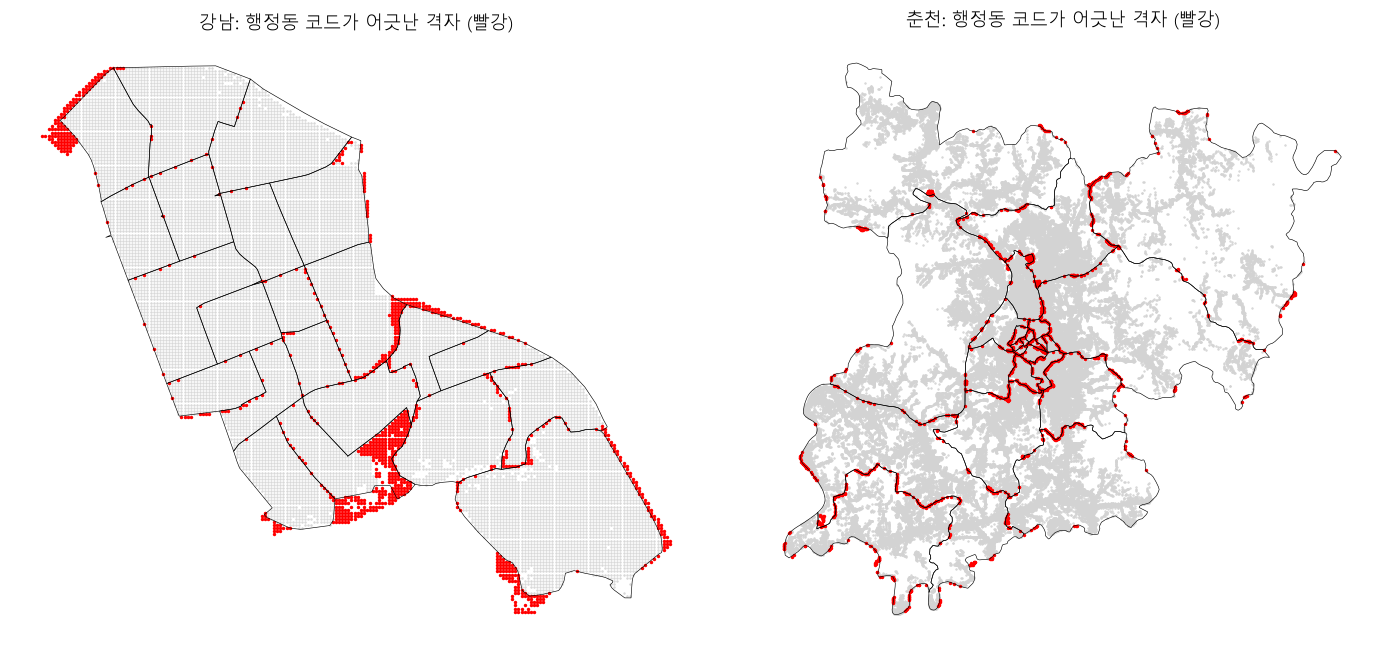

In [9]:
# 어긋난 격자가 "자기 동 경계선"에서 얼마나 떨어져 있는지 잰다. 가까우면 경계에 걸친 격자일 뿐
own = dong5179.set_index('adm_cd').geometry                  # 코드 -> 동 도형
miss = sj[sj['status'].ne('일치')].copy()
# zip: 두 목록을 짝지어 하나씩 꺼냄. .boundary = 도형의 테두리 선, .distance(점) = 선과 점 사이 거리(m)
miss['dist'] = [own[c].boundary.distance(p) for c, p in zip(miss['adm_cd'], miss.geometry)]
display(miss['dist'].quantile([0.5, 0.9, 0.99, 1]).round(0).to_frame('자기 동 경계까지 거리(m)'))
print(f"어긋난 격자 중 100m 이내: {miss['dist'].le(100).mean():.1%}")

# 유동인구로 가중한 일치율: 사람이 많은 격자가 잘 맞으면 실제 분석에는 문제가 거의 없음
w = flow_age.groupby(['x', 'y'], as_index=False)['total'].sum()     # 격자별 6개월 합계
sjw = sj.merge(w, on=['x', 'y'])
display((sjw.groupby('status')['total'].sum() / sjw['total'].sum() * 100).round(1).to_frame('유동인구 비중(%)'))

# 지도: 연한 회색 = 일치, 빨간 점 = 어긋난 격자, 검은 선 = 행정동 경계
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, r in zip(axes, REGIONS):
    s = sj[sj['region'].eq(r)]
    s[s['status'].eq('일치')].plot(ax=ax, color='lightgray', markersize=0.3)
    s[s['status'].ne('일치')].plot(ax=ax, color='red', markersize=1.5)
    dong5179[dong5179['region'].eq(r)].boundary.plot(ax=ax, color='k', lw=0.4)
    ax.set_title(f'{r}: 행정동 코드가 어긋난 격자 (빨강)')
    ax.set_axis_off()                                     # 지도라서 축 눈금은 숨김
plt.tight_layout()
plt.show()

시사점: 어긋난 격자는 자기 동 경계선에서 중앙값 36m, 90%가 228m 안에 있고 76.2%가 100m 이내다. 지도에서도 빨간 점이 동 경계선을 따라 늘어서 있다.<br>유동인구로 가중하면 일치율은 96.2%다. 어긋남은 경계에 걸친 격자 문제일 뿐 좌표계 문제가 아니므로, 행정동 단위 집계에는 adm_cd를 그대로 써도 된다.

### 2-4. 다른 좌표계로 가정하면?

In [10]:
# 한국에서 자주 쓰는 다른 좌표계로 가정해도 맞는지 본다. 틀린 좌표계면 점이 엉뚱한 곳에 떨어짐


def match_rate(crs, dx=0, dy=0):
    """x, y를 crs 좌표계라고 가정하고(필요하면 dx, dy만큼 옮겨서) 행정동 일치율을 계산한다."""
    p = gpd.GeoDataFrame(cells, geometry=gpd.points_from_xy(cells['x'] + dx, cells['y'] + dy), crs=crs)
    p = p.to_crs(dong.crs)                                                 # 경계와 같은 위도 경도로 바꿈
    j = gpd.sjoin(p, dong[['adm_cd', 'geometry']].rename(columns={'adm_cd': 'adm_cd_sj'}),
                  how='left', predicate='within')
    j = j[~j.index.duplicated()]
    return j['adm_cd'].eq(j['adm_cd_sj']).mean()


rates = {f'EPSG:{crs}': match_rate(crs) for crs in [5179, 5181, 5186, 5174]}
rates['EPSG:5179, 25m 옮김'] = match_rate(5179, 25, 25)                    # 격자 모서리 -> 중심이라고 가정
display((pd.Series(rates) * 100).round(1).to_frame('일치율(%)'))

,일치율(%)
EPSG:5179,97.60
EPSG:5181,0.00
EPSG:5186,0.00
EPSG:5174,0.00
"EPSG:5179, 25m 옮김",97.10


시사점: 5179로 가정하면 일치율 97.6%, 5181, 5186, 5174로 가정하면 0.0%다. 좌표를 25m 옮기면 97.1%로 오히려 조금 낮아진다.<br>x, y는 EPSG:5179가 확실하고 좌표를 옮기지 않고 그대로 쓰면 된다.

**결정**: 유동인구를 행정동 단위로 묶을 때 어느 코드를 쓸지 적어 둔다. (예: "`adm_cd`(block_cd 앞 8자리)를 그대로 쓴다. 공간조인은 검증용으로만 썼다")

- 결정:
- 이유:

### 2장 정리
- **본 것**:
- **나온 것**:
- **시사점**:

## 3. 01번이 남긴 문제 확인
01번 노트북이 "03번에서 확인"으로 남겨둔 두 가지를 본다.
1. 요일 파일에서 **평일은 사람이 있는데 토, 일요일만 정확히 0**인 행이 5.8%. 진짜 0(주말에 텅 비는 업무지구)인가, 값이 삭제(마스킹)된 것인가?
2. 같은 달이라도 **파일마다 격자 수가 다름**. 세 파일을 격자 단위로 합치면 무슨 일이 생기나?

### 3-1. 파일마다 격자 집합이 얼마나 겹치나

In [11]:
# 달마다 세 파일의 격자 집합이 얼마나 겹치는지 센다.
def cell_set(df, ym):
    """그 달의 (x, y) 격자 집합. set = 중복 없는 모음 (&: 교집합, |: 합집합, -: 차집합)"""
    d = df[df['ym'].eq(ym)]
    return set(zip(d['x'], d['y']))                    # zip으로 x, y를 짝지어 (x, y) 묶음으로


rows = []
for ym in sorted(flow_age['ym'].unique()):
    A, T, W = cell_set(flow_age, ym), cell_set(flow_time, ym), cell_set(flow_wkdy, ym)
    rows.append({'ym': ym, 'age': len(A), 'time': len(T), 'wkdy': len(W), '세 파일 공통': len(A & T & W),
                 'wkdy에만(W - A)': len(W - A), 'A - W': len(A - W), 'A - T': len(A - T), '합집합': len(A | T | W)})
overlap = pd.DataFrame(rows).set_index('ym')
display(overlap)

# wkdy에만 있는 격자는 어느 지역인가 (2025-10)
w10 = flow_wkdy[flow_wkdy['ym'].eq('202510')].set_index(['x', 'y'])
a10 = flow_age[flow_age['ym'].eq('202510')].set_index(['x', 'y'])
only_w = w10.index.difference(a10.index)               # wkdy에는 있고 age에는 없는 격자
display(w10.loc[only_w, 'region'].value_counts().to_frame('wkdy에만 있는 격자 수 (10월)'))

,age,time,wkdy,세 파일 공통,wkdy에만(W - A),A - W,A - T,합집합
ym,,,,,,,,
202507,98069,94042,117718,92784,19649,0,5285,117718
202508,99056,95316,118849,93983,19793,0,5073,118849
202509,99410,95027,119755,94002,20345,0,5408,119755
202510,100692,97823,120532,95919,20352,512,4773,121044
202511,100390,95769,122140,94210,21750,0,6180,122140
202512,98298,92498,121171,91165,22873,0,7133,121171


,wkdy에만 있는 격자 수 (10월)
region,
춘천,20249
강남,103


시사점: 같은 달에도 파일마다 격자 수가 다르다. 2025-10 기준 age 100,692개, time 97,823개, wkdy 120,532개이고 세 파일 공통은 95,919개다. wkdy에만 있는 격자가 20,352개인데 그중 20,249개가 춘천이다.<br>10월을 빼면 age 격자는 모두 wkdy 안에 들어 있어서, wkdy가 가장 넓게 격자를 담은 파일이다.

### 3-2. 합칠 때 잃는 것은 얼마나 되나

In [12]:
# 합칠 때 빠지는 격자가 유동인구로 치면 얼마나 되는지 (2025-10)
t10 = flow_time[flow_time['ym'].eq('202510')].set_index(['x', 'y'])
only_a = a10.index.difference(t10.index)               # age에는 있고 time에는 없는 격자

lost = pd.Series({
    'wkdy에만 있는 격자의 total 비중(%)': w10.loc[only_w, 'total'].sum() / w10['total'].sum() * 100,
    'age 중 time에 없는 격자의 total 비중(%)': a10.loc[only_a, 'total'].sum() / a10['total'].sum() * 100,
    'wkdy에만 있는 격자의 total 중앙값': w10.loc[only_w, 'total'].median(),
    'wkdy 전체 격자의 total 중앙값': w10['total'].median(),
})
display(lost.map('{:,.3f}'.format).to_frame('값'))     # map: 소수 셋째 자리까지 글자로 (아주 작은 비중도 보이게)

,값
wkdy에만 있는 격자의 total 비중(%),0.015
age 중 time에 없는 격자의 total 비중(%),0.005
wkdy에만 있는 격자의 total 중앙값,0.380
wkdy 전체 격자의 total 중앙값,7.440


시사점: wkdy에만 있는 격자는 wkdy 전체 유동인구의 0.015%, age 중 time에 없는 격자는 0.005%뿐이다. wkdy에만 있는 격자의 중앙값은 0.38로 전체 중앙값 7.44보다 훨씬 작다.<br>빠지는 격자는 사람이 거의 없는 곳이라 세 파일을 공통 격자로 합쳐도 총량은 거의 그대로다. 다만 "격자 수"를 비교하는 분석은 파일마다 달라서 하지 않는다.

### 3-3. 주말만 0인 격자의 크기

In [13]:
# 01번 4-4와 같은 조건: 평일(월~금)은 사람이 있는데 토, 일요일은 정확히 0인 행
WEEKDAY_COLS, WEEKEND_COLS = WKDY_COLS[:5], WKDY_COLS[5:]
flow_wkdy['wd_mean'] = flow_wkdy[WEEKDAY_COLS].mean(axis=1)          # 평일 평균
flow_wkdy['weekend_zero'] = (flow_wkdy[WEEKEND_COLS].eq(0).all(axis=1)   # all(axis=1): 한 행의 토, 일이 모두 0인가
                             & flow_wkdy[WEEKDAY_COLS].sum(axis=1).gt(0))
wz = flow_wkdy['weekend_zero']
print(f'평일 > 0 인데 주말 = 0 인 행: {wz.sum():,}개 ({wz.mean():.1%})')
wz_region = flow_wkdy.groupby('region')['weekend_zero'].agg(행수='sum', 비율='mean')
wz_region['비율'] = wz_region['비율'] * 100
display(wz_region.rename(columns={'비율': '비율(%)'}).round(1))
# 달별 비율: pivot_table로 ym × region 표
display((flow_wkdy.pivot_table(index='ym', columns='region', values='weekend_zero', aggfunc='mean') * 100).round(1))

# 주말 0 행과 나머지 행의 평일 평균 분포
display(flow_wkdy.groupby('weekend_zero')['wd_mean'].quantile([0.5, 0.9]).unstack().round(2))
print('값의 최솟값(0 제외):', flow_wkdy[WKDY_COLS].replace(0, np.nan).min().min())

# 평일 평균 구간별 주말 0 비율: pd.cut으로 구간을 나눔
bins = pd.cut(flow_wkdy['wd_mean'], [0, 0.5, 1, 2, 5, 10, 1e9])
display((flow_wkdy.groupby(bins, observed=True)['weekend_zero'].mean() * 100).round(1).to_frame('주말 0 비율(%)'))

# 반대 경우: 월~금이 모두 0인데 주말은 0보다 큰 행
rev = flow_wkdy[WEEKDAY_COLS].eq(0).all(axis=1) & flow_wkdy[WEEKEND_COLS].sum(axis=1).gt(0)
print(f'반대 경우(평일 모두 0, 주말 > 0): {rev.mean():.1%}')
print(f"주말 0 행의 평일 유동인구 비중: {flow_wkdy.loc[wz, WEEKDAY_COLS].sum().sum() / flow_wkdy[WEEKDAY_COLS].sum().sum():.2%}")

평일 > 0 인데 주말 = 0 인 행: 41,670개 (5.8%)


,행수,비율(%)
region,,
강남,202,0.20
춘천,41468,6.60


region,강남,춘천
ym,,
202507,0.20,5.90
202508,0.20,5.90
202509,0.20,6.40
202510,0.20,6.60
202511,0.20,6.80
202512,0.20,7.90


,0.50,0.90
weekend_zero,,
False,1.14,105.03
True,0.08,0.91


값의 최솟값(0 제외): 0.03


,주말 0 비율(%)
wd_mean,
"(0.0, 0.5]",12.80
"(0.5, 1.0]",3.80
"(1.0, 2.0]",2.80
"(2.0, 5.0]",1.70
"(5.0, 10.0]",0.90
"(10.0, 1000000000.0]",0.10


반대 경우(평일 모두 0, 주말 > 0): 1.9%


주말 0 행의 평일 유동인구 비중: 0.03%


시사점: 평일은 사람이 있는데 주말만 0인 행은 41,670개(5.8%)이고, 강남은 202개(0.2%), 춘천은 41,468개(6.6%)다. 이 행들의 평일 평균은 중앙값 0.08로, 값의 최솟값(0.03)과 거의 같은 "거의 0"인 격자다.<br>평일 평균이 0.5 이하인 격자에서는 12.8%가 주말 0이지만 10을 넘는 격자에서는 0.1%뿐이고, 반대로 평일만 모두 0인 행도 1.9% 있다. 주말 0 행의 유동인구는 전체의 0.03%라서 분석 결과에 영향이 거의 없다.

### 3-4. 주말만 0인 격자는 어디에 있나

,주말 0 행 수
adm_cd,
남산면,8104
남면,7384
동면,3666
사북면,3414
북산면,3269
동산면,3181
신동면,2597
서면,2584
신북읍,2490


,동 안에서 주말 0 비율(%)
adm_cd,
남면,17.10
근화동,15.70
남산면,9.30
신동면,8.60
북산면,7.80
동산면,6.00
동면,5.80
사북면,5.70
신북읍,4.50


,강남 주말 0 행 수
adm_cd,
세곡동,101
개포2동,44
일원본동,36
압구정동,12
개포4동,6


,격자 수
주말 0인 달 수,
1,2655
2,1915
3,905
4,1174
5,1356
6,3499


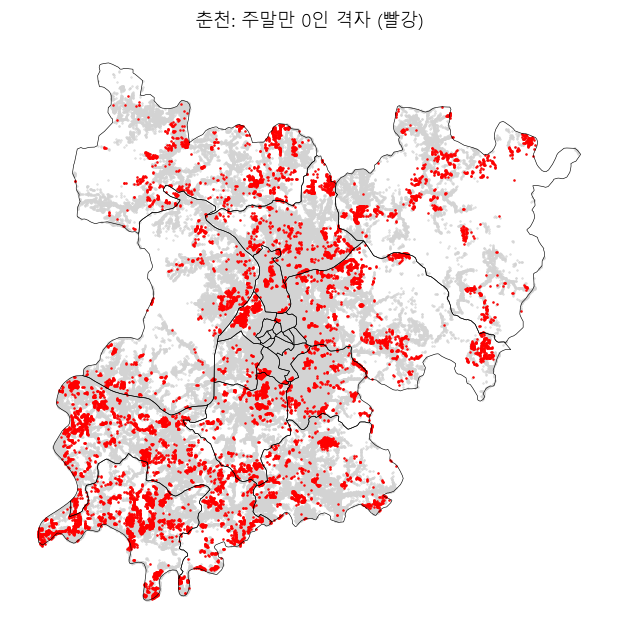

In [14]:
# 주말 0 행이 어느 행정동에 몰려 있는지
names = dong_codes.set_index('adm_cd')['dong']                       # 코드 -> 동 이름
top_n = flow_wkdy.loc[wz].groupby('adm_cd').size().nlargest(10)
display(top_n.rename(index=names).to_frame('주말 0 행 수'))           # rename(index=...): 코드를 동 이름으로 바꿔 보기

top_rate = flow_wkdy.groupby('adm_cd')['weekend_zero'].mean().nlargest(10) * 100
display(top_rate.rename(index=names).round(1).to_frame('동 안에서 주말 0 비율(%)'))

gn = flow_wkdy.loc[wz & flow_wkdy['region'].eq('강남')].groupby('adm_cd').size().nlargest(5)
display(gn.rename(index=names).to_frame('강남 주말 0 행 수'))

# 격자별로 6개월 중 몇 달이 주말 0이었나
months_wz = flow_wkdy.groupby(['x', 'y'])['weekend_zero'].sum()
display(months_wz[months_wz.gt(0)].value_counts().sort_index().to_frame('격자 수').rename_axis('주말 0인 달 수'))

# 춘천 지도: 회색 = 모든 격자, 빨강 = 한 번이라도 주말 0인 격자
cc = flow_wkdy[flow_wkdy['region'].eq('춘천')].drop_duplicates(['x', 'y'])
cc_wz = flow_wkdy[flow_wkdy['region'].eq('춘천') & wz].drop_duplicates(['x', 'y'])
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(cc['x'], cc['y'], s=0.2, color='lightgray')
ax.scatter(cc_wz['x'], cc_wz['y'], s=0.4, color='red')
dong5179[dong5179['region'].eq('춘천')].boundary.plot(ax=ax, color='k', lw=0.4)
ax.set_aspect('equal')                      # 가로 세로 비율을 같게 (지도가 찌그러지지 않게)
ax.set_axis_off()
ax.set_title('춘천: 주말만 0인 격자 (빨강)')
plt.show()

시사점: 주말 0 행은 남산면, 남면, 동면, 사북면, 북산면 같은 춘천 외곽 읍면에 몰려 있고, 강남은 세곡동(101행), 개포2동, 일원본동 순이다. 역삼, 삼성 같은 업무지구가 아니다.<br>따라서 "주말에 텅 비는 업무지구"가 아니라 사람이 아주 적은 외곽 격자에서 작은 값이 0으로 떨어진 것(반올림 또는 표본 잡음)으로 보인다. 6개월 내내 주말 0인 격자도 3,499개 있지만 총량이 거의 0이라 그대로 두어도 된다.

### 3장 정리
- **본 것**: 파일별 격자 집합의 차이(3-1), 합칠 때 잃는 총량(3-2), 주말만 0인 행의 크기와 위치(3-3, 3-4)
- **나온 것**:
  - 격자 수는 파일마다 다르지만(10월 기준 age 100,692 / time 97,823 / wkdy 120,532), **wkdy에만 있는 격자는 총량의 0.015%**, 중앙값 0.38로 사람이 거의 없는 곳이다
  - 주말만 0인 행 41,670개(5.8%)는 **평일 평균 중앙값이 0.08**로 값의 최솟값(0.03) 수준이다. 평일 평균 0.5 이하 격자는 12.8%가 주말 0인데 10 초과 격자는 0.1%뿐이다
  - 위치는 업무지구가 아니라 **춘천 외곽 읍면**(남산면, 남면, 동면)이고 강남은 202개(0.2%)뿐이다. **반대 경우(평일만 0)도 1.9%** 있다
- **시사점**:
  - 주말 0은 "지워진 값"이 아니라 **작은 값이 반올림과 표본 잡음으로 0이 된 것**이다. 총량의 0.03%라 그대로 두고 쓴다
  - 세 파일은 **공통 격자로 합쳐도 총량이 거의 그대로**다. 다만 파일마다 격자 집합이 달라 **"격자 수"를 세는 분석은 하지 않는다**


## 4. 시간 축 프로파일 (월, 시간대, 요일)
사람이 **언제** 많이 나오는지 본다. 월별 흐름은 폭염(8월)과 추석(10월) 달에 유동이 줄었는지,
시간대와 요일은 02번에서 본 카드 매출 패턴과 같은지 비교하는 게 목적이다.

### 4-1. 지역별 월별 총량

age          time        wkdy / 7       
region     강남     춘천     강남     춘천       강남     춘천
ym                                                
202507 754.30 179.60 754.30 179.90   747.60 179.90
202508 718.40 186.10 718.50 186.40   728.00 186.50
202509 759.90 195.50 760.00 195.80   756.60 195.50
202510 713.20 188.90 713.30 189.20   705.80 188.90
202511 745.90 186.10 745.90 186.40   756.20 186.90
202512 732.10 177.40 732.10 177.70   726.00 177.40

강남 / 춘천: [4.2, 3.86, 3.89, 3.78, 4.01, 4.13]


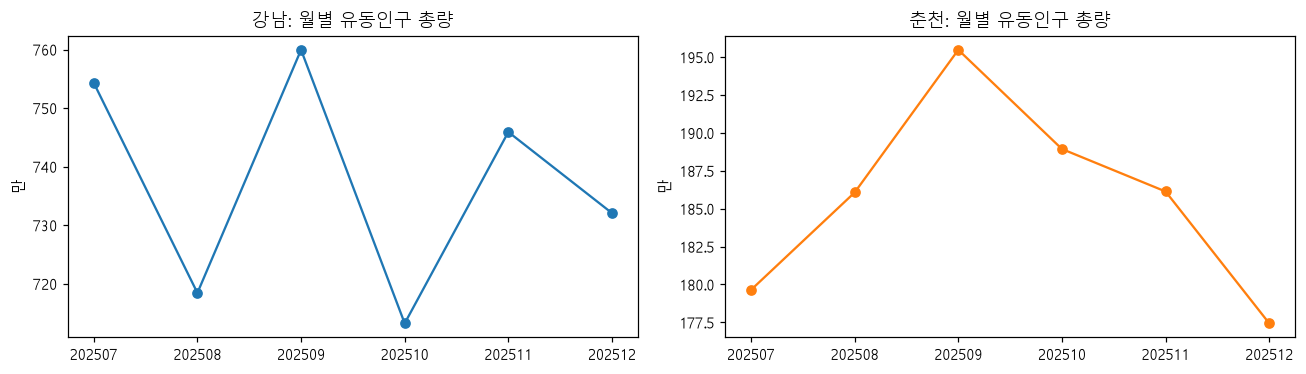

In [15]:
# 지역별 월별 유동인구 총량 (만). 세 파일로 각각 계산해서 거의 같은지 확인
monthly = pd.concat({
    'age': flow_age.groupby(['ym', 'region'])['total'].sum(),
    'time': flow_time.groupby(['ym', 'region'])['total'].sum(),
    'wkdy / 7': flow_wkdy.groupby(['ym', 'region'])['total'].sum() / 7,     # 요일 파일은 7일치라 7로 나눔
}, axis=1).unstack('region') / 1e4
display(monthly.round(1))

flow_m = monthly['age']                                     # 이후에는 age 기준을 씀 (열: 강남, 춘천)
print('강남 / 춘천:', (flow_m['강남'] / flow_m['춘천']).round(2).tolist())

# 규모가 4배 차이 나서 그래프를 좌우 2개로
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
for ax, r in zip(axes, REGIONS):
    ax.plot(flow_m.index, flow_m[r], marker='o', color=REGION_COLOR[r])
    ax.set(title=f'{r}: 월별 유동인구 총량', ylabel='만')
plt.tight_layout()
plt.show()

시사점: 월별 유동인구 총량은 강남이 713만(10월)~760만(9월), 춘천이 177만(12월)~196만(9월)으로 강남이 춘천의 약 4배다. 세 파일로 계산한 값이 거의 같다.<br>강남은 8월(718만)과 10월(713만)에 낮고, 춘천은 9월에 가장 많다. 강남 8월의 하락이 폭염 때문인지 휴가철 때문인지는 월 단위 자료로는 구분할 수 없다.

### 4-2. 월별 지수: 유동인구, 지하철, 카드 매출 비교

유동인구           지하철            카드       
region      강남     춘천     강남     춘천     강남     춘천
2025-07 100.00 100.00 100.00 100.00 100.00 100.00
2025-08  95.20 103.60  91.90 106.40  96.20 101.50
2025-09 100.70 108.80 101.10 116.00  99.60 101.70
2025-10  94.60 105.20  86.70 121.50  96.20 106.90
2025-11  98.90 103.60  99.00 120.20 101.80 104.30
2025-12  97.10  98.80 102.60 105.00 109.50  99.50

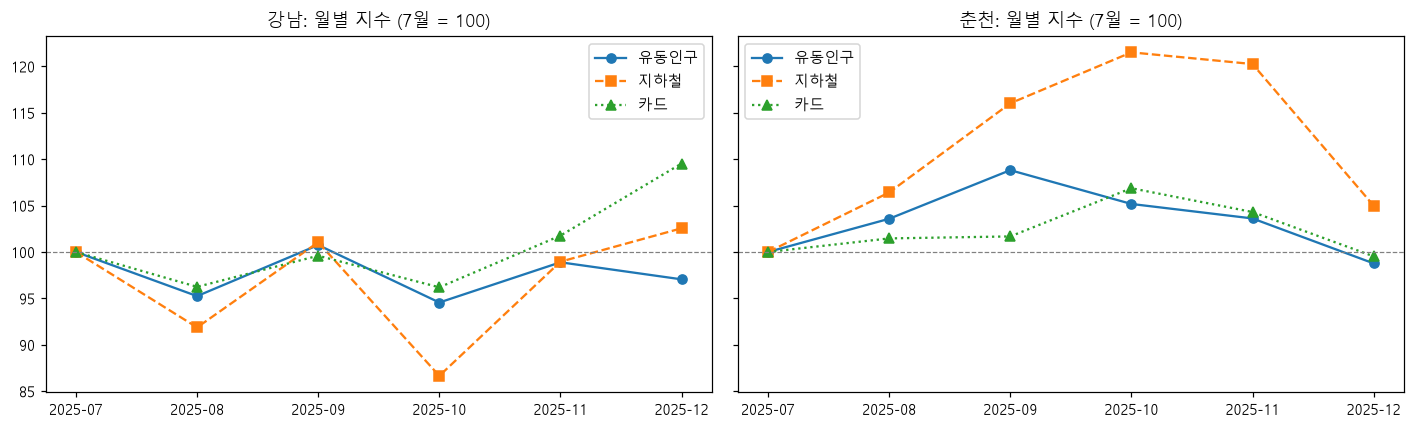

In [16]:
# 세 자료를 "7월 = 100" 지수로 맞춰 겹쳐 본다.
flow_idx = flow_m / flow_m.iloc[0] * 100
flow_idx.index = pd.to_datetime(flow_idx.index, format='%Y%m')     # '202507' -> 2025-07-01 날짜로

# 지하철: 2025 하반기 강남, 춘천 역의 (승차 + 하차) 일합계 -> 월별 일평균
sw = subway[subway['region'].ne('기타') & subway['date'].between('2025-07-01', '2025-12-31')]
sw_daily = sw.assign(total=sw['board'] + sw['alight']).groupby(['date', 'region'])['total'].sum().unstack('region')
sw_m = sw_daily.resample('MS').mean()               # resample('MS'): 월 단위로 묶기 (MS = 월 첫날 기준)
card_m = sales.resample('MS').mean()

idx = pd.concat({'유동인구': flow_idx, '지하철': sw_m / sw_m.iloc[0] * 100, '카드': card_m / card_m.iloc[0] * 100}, axis=1)
idx.index = idx.index.strftime('%Y-%m')
display(idx.round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, r in zip(axes, REGIONS):
    for src, style in [('유동인구', 'o-'), ('지하철', 's--'), ('카드', '^:')]:
        ax.plot(idx.index, idx[(src, r)], style, label=src)
    ax.axhline(100, ls='--', color='gray', lw=0.8)
    ax.set(title=f'{r}: 월별 지수 (7월 = 100)')
    ax.legend()
plt.tight_layout()
plt.show()


시사점: 7월을 100으로 맞추면 강남은 8월에 유동 95.2, 지하철 91.9, 카드 96.2로 세 자료가 함께 눌리고, 추석이 있는 10월에도 94.6, 86.7, 96.2로 함께 낮다. 12월에는 카드만 109.5로 크게 오른다(연말 소비).<br>춘천은 지하철이 10월 121.5까지 오르는 등 가을 관광철에 크게 늘고, 유동과 카드도 9~10월에 높다.

### 4-3. 시간대 프로파일 (24시간)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
region,,,,,,,,,,,,,,,,,,,,,,,,
강남,1.18,0.79,0.56,0.46,0.45,0.72,1.53,3.10,5.12,5.60,5.78,6.49,7.08,7.03,6.83,6.96,7.07,7.44,7.21,5.40,4.41,3.84,3.10,1.86
춘천,1.43,0.97,0.71,0.63,0.64,0.96,1.73,3.16,5.78,5.27,5.74,6.34,6.66,6.67,6.65,6.85,7.08,7.22,7.07,5.40,4.62,3.79,2.73,1.90


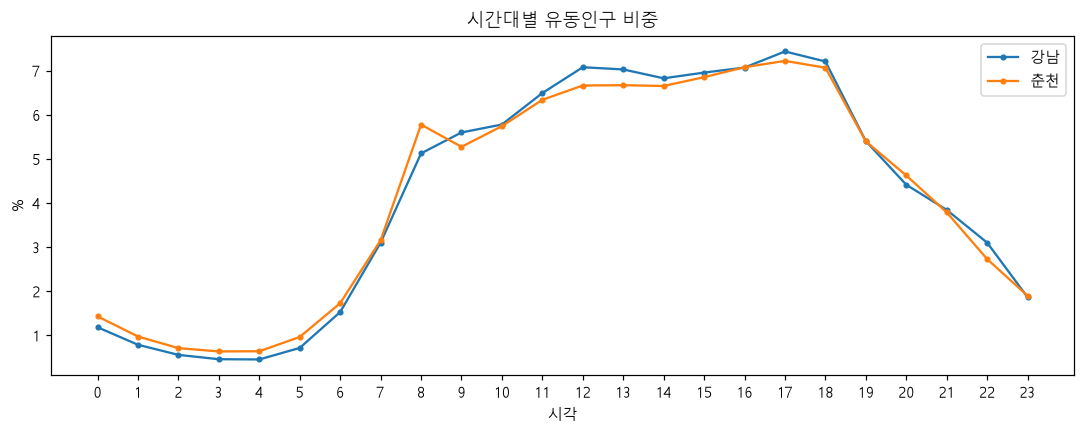

가장 많은 시각: {'강남': 17, '춘천': 17} / 가장 적은 시각: {'강남': 4, '춘천': 3}


TMST_08  TMST_13  TMST_18  TMST_21
region ym                                        
강남     202507     5.26     6.98     7.31     3.91
       202508     4.98     7.00     7.24     4.00
       202509     5.40     6.91     7.29     3.83
       202510     5.03     7.06     7.06     3.83
       202511     5.11     7.10     7.17     3.75
       202512     4.95     7.11     7.16     3.75
춘천     202507     5.89     6.54     7.13     3.96
       202508     5.38     6.52     7.08     4.02
       202509     6.15     6.44     7.26     3.87
       202510     5.52     6.79     7.07     3.72
       202511     5.89     6.80     6.97     3.57
       202512     5.83     6.96     6.89     3.59

In [17]:
# 지역별 24시간 비중(%): 지역마다 합이 100
tp = flow_time.groupby('region')[TIME_COLS].sum()
tp = tp.div(tp.sum(axis=1), axis=0) * 100              # div(..., axis=0): 행마다 그 행의 합으로 나눔
tp.columns = range(24)                                 # 열 이름을 0~23시 숫자로
display(tp.T.round(2).T)

fig, ax = plt.subplots()
for r in REGIONS:
    ax.plot(tp.columns, tp.loc[r], marker='o', ms=3, color=REGION_COLOR[r], label=r)
ax.set(title='시간대별 유동인구 비중', xlabel='시각', ylabel='%', xticks=range(24))
ax.legend()
plt.show()
print('가장 많은 시각:', tp.idxmax(axis=1).to_dict(), '/ 가장 적은 시각:', tp.idxmin(axis=1).to_dict())

# 달마다 모양이 바뀌는지: 8시, 13시, 18시, 21시 비중
tpm = flow_time.groupby(['region', 'ym'])[TIME_COLS].sum()
tpm = tpm.div(tpm.sum(axis=1), axis=0) * 100
display(tpm[['TMST_08', 'TMST_13', 'TMST_18', 'TMST_21']].round(2))

시사점: 두 지역 모두 17시에 유동인구가 가장 많고(강남 7.44%, 춘천 7.22%), 3~4시에 가장 적다. 강남은 점심 무렵(12~13시 약 7.1%)이 조금 더 많고 춘천은 새벽이 조금 더 많지만, 하루 모양은 거의 같다.<br>21시 비중은 강남 3.91%에서 3.75%, 춘천 3.96%에서 3.59%로 7월보다 12월에 조금 줄어든다. 여름 밤에 사람이 더 오래 나와 있다는 뜻이다.

### 4-4. 카드 시간대 4구간과 비교

00_05  06_11  12_17  18_23
     region                            
유동인구 강남       4.20  27.60  42.40  25.80
     춘천       5.30  28.00  41.10  25.50
카드   강남       2.40  22.20  51.40  24.10
     춘천       2.10  20.80  50.10  27.10

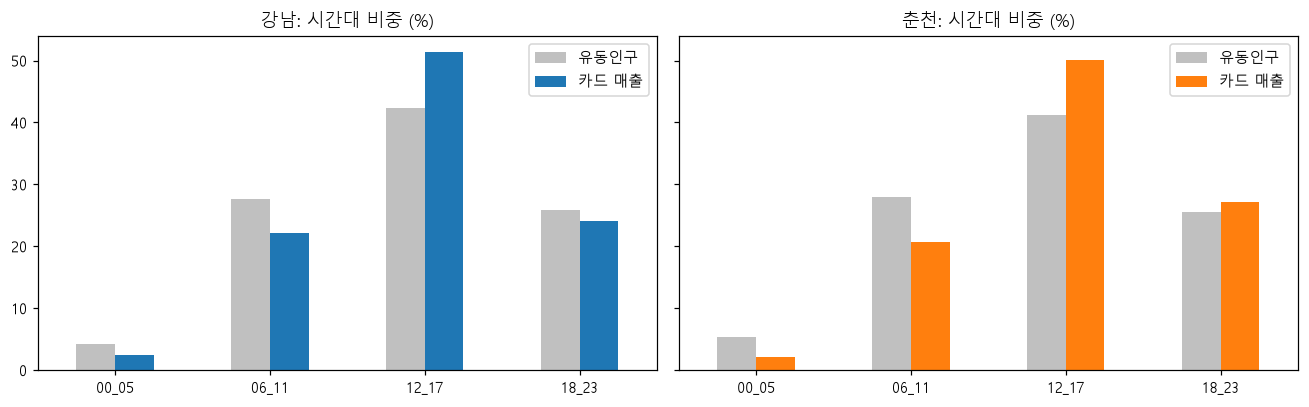

In [18]:
# 유동인구 24시간을 카드와 같은 4구간으로 묶어서 비교
SLOT = {'00_05': range(0, 6), '06_11': range(6, 12), '12_17': range(12, 18), '18_23': range(18, 24)}
flow_slot = pd.DataFrame({s: tp[list(hours)].sum(axis=1) for s, hours in SLOT.items()})

# 카드(base1) 시간대 비중: 02번 6-1과 같은 계산
card_slot = base1.pivot_table(index='region', columns='time_gb', values='amount', aggfunc='sum')
card_slot = card_slot.div(card_slot.sum(axis=1), axis=0) * 100

slot = pd.concat({'유동인구': flow_slot, '카드': card_slot})
display(slot.round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, r in zip(axes, REGIONS):
    pd.DataFrame({'유동인구': flow_slot.loc[r], '카드 매출': card_slot.loc[r]}).plot(
        kind='bar', ax=ax, rot=0, color=['silver', REGION_COLOR[r]])
    ax.set(title=f'{r}: 시간대 비중 (%)', xlabel='')
plt.tight_layout()
plt.show()

시사점: 유동인구는 12~17시에 강남 42.4%, 춘천 41.1%인데 카드 매출은 이 시간에 강남 51.4%, 춘천 50.1%가 몰린다. 반대로 06~11시는 유동 27~28%, 매출 21~22%다.<br>오후에는 사람 수에 비해 돈을 더 많이 쓴다. 폭염 피크(14~16시)에 사람이 줄면 매출은 사람이 준 비율보다 더 크게 줄 수 있다.

### 4-5. 요일 프로파일

월    화    수    목    금    토    일
     region                                   
유동인구 강남     1.05 1.09 1.09 1.09 1.09 0.87 0.71
     춘천     1.00 1.01 1.01 1.01 1.04 1.01 0.92
카드   강남     1.03 1.07 1.02 1.04 1.12 1.03 0.69
     춘천     0.97 0.94 0.95 0.96 1.09 1.22 0.86

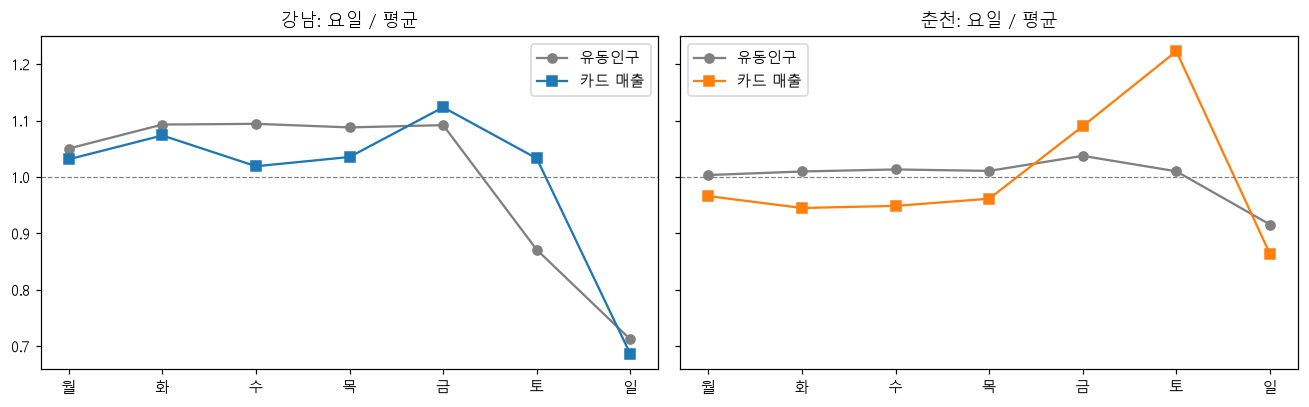

월    화    수    목    금    토    일
region ym                                       
강남     202507 1.05 1.09 1.09 1.10 1.11 0.86 0.70
       202508 1.07 1.12 1.10 1.12 1.04 0.85 0.70
       202509 1.05 1.08 1.07 1.09 1.11 0.88 0.71
       202510 1.00 1.07 1.12 1.12 1.09 0.88 0.72
       202511 1.06 1.09 1.09 1.07 1.09 0.88 0.71
       202512 1.06 1.10 1.09 1.03 1.10 0.88 0.73
춘천     202507 1.01 1.01 1.00 1.00 1.05 1.02 0.91
       202508 1.01 1.01 0.98 1.01 1.05 1.03 0.92
       202509 1.02 1.03 1.01 1.03 1.03 0.98 0.90
       202510 0.97 0.98 1.02 1.02 1.02 1.03 0.96
       202511 1.01 1.01 1.02 1.00 1.03 1.02 0.91
       202512 1.00 1.03 1.04 1.00 1.05 0.98 0.89

In [19]:
# 요일별 유동인구 / 7개 요일 평균 (1보다 크면 평균보다 많은 요일)
wp = flow_wkdy.groupby('region')[WKDY_COLS].sum()
wp = wp.div(wp.mean(axis=1), axis=0)
wp.columns = DOW

# 카드: 공휴일 뺀 날로 요일 평균 / 전체 평균 (02번 4-1과 같은 계산)
s_nh = sales[~cal['is_holiday'].reindex(sales.index)]            # reindex: sales와 같은 날짜 순서로 맞춤
card_dow = s_nh.groupby(s_nh.index.dayofweek).mean() / s_nh.mean()
card_dow.index = DOW

dow_cmp = pd.concat({'유동인구': wp, '카드': card_dow.T})
display(dow_cmp.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, r in zip(axes, REGIONS):
    ax.plot(DOW, wp.loc[r], 'o-', color='gray', label='유동인구')
    ax.plot(DOW, card_dow[r], 's-', color=REGION_COLOR[r], label='카드 매출')
    ax.axhline(1, ls='--', color='gray', lw=0.8)
    ax.set(title=f'{r}: 요일 / 평균')
    ax.legend()
plt.tight_layout()
plt.show()

# 달마다: 추석이 있는 10월에 모양이 바뀌는지
wpm = flow_wkdy.groupby(['region', 'ym'])[WKDY_COLS].sum()
wpm = wpm.div(wpm.mean(axis=1), axis=0)
wpm.columns = DOW
display(wpm.round(2))

시사점: 강남 유동인구는 평일 1.05~1.09, 토요일 0.87, 일요일 0.71이고 카드 매출도 일요일 0.69로 비슷하게 빠진다. 하지만 토요일은 유동 0.87인데 매출 1.03으로, 사람은 줄어도 쇼핑 매출은 그대로다. (관광 데이터를 보면 토요일 매출이 유지되는 이유를 확정 지을 수 있을 듯)<br>춘천은 유동인구가 토요일 1.01로 평일과 거의 같은데 매출은 1.22다. 사람 수보다 "누가 오는가"(주말 외지인, 02번 9장)가 춘천 주말 매출을 만든다. 10월 강남 월요일(1.00)은 추석 연휴(10/6) 때문에 낮다.

### 4장 정리
- **본 것**:
- **나온 것**:
- **시사점**:

## 5. 성별 × 연령 구성
누가 돌아다니는지 본다. 카드 매출의 연령 구성과 비교하면 "많이 다니지만 덜 쓰는 연령", "적게 다니지만 많이 쓰는 연령"이 보인다.

### 5-1. 지역별 성별 × 연령 피라미드

10대  20대  30대   40대  50대  60대 이상
region                                     
강남     남성 4.40 6.60 9.80 11.00 9.70    9.80
       여성 4.50 8.80 9.50  9.50 7.30    9.00
춘천     남성 7.40 7.30 6.40  8.60 9.20   12.00
       여성 6.90 6.80 6.10  8.30 8.40   12.70

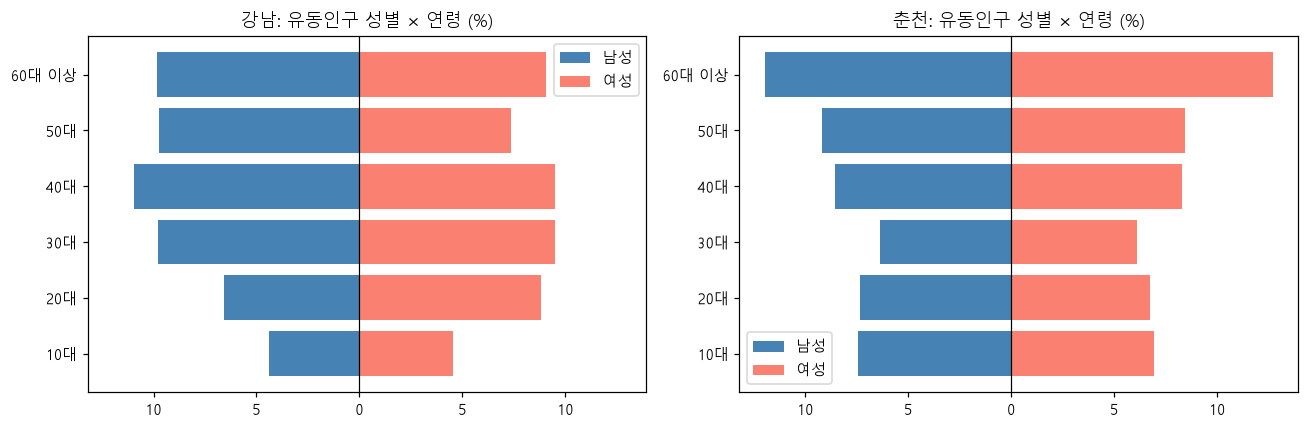

,남성 비중,10대,20대 + 30대,60대 이상
region,,,,
강남,51.30,9.00,34.70,18.90
춘천,50.80,14.30,26.60,24.70


In [20]:
# 지역별 성별 × 연령 비중(%)
ap = flow_age.groupby('region')[AGE_COLS].sum()
ap = ap.div(ap.sum(axis=1), axis=0) * 100
# 열 이름 'MAN_FLOW_POP_CNT_20G' -> (남성, 20대) 로 나누기. split('_'): '_'로 나눈 조각 목록
AGE_NAME = {'10G': '10대', '20G': '20대', '30G': '30대', '40G': '40대', '50G': '50대', '60GU': '60대 이상'}
ap.columns = pd.MultiIndex.from_tuples(
    [('남성' if c.split('_')[0] == 'MAN' else '여성', AGE_NAME[c.split('_')[-1]]) for c in ap.columns])
pyr = ap.stack(level=0, future_stack=True)             # stack: 성별을 행으로 내림 -> 행 (지역, 성별), 열 연령
display(pyr.round(1))

AGES = list(AGE_NAME.values())
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for ax, r in zip(axes, REGIONS):
    ax.barh(AGES, -pyr.loc[(r, '남성'), AGES], color='steelblue', label='남성')   # 남성은 음수로 -> 왼쪽
    ax.barh(AGES, pyr.loc[(r, '여성'), AGES], color='salmon', label='여성')
    ax.axvline(0, color='k', lw=0.8)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{abs(v):g}'))    # 눈금을 절댓값으로
    ax.set(title=f'{r}: 유동인구 성별 × 연령 (%)')
    ax.legend()
plt.tight_layout()
plt.show()

summary_age = pd.DataFrame({
    '남성 비중': pyr.xs('남성', level=1).sum(axis=1),                 # xs: 한 단계(성별)에서 '남성'만 골라냄
    '10대': ap.xs('10대', axis=1, level=1).sum(axis=1),
    '20대 + 30대': ap.xs('20대', axis=1, level=1).sum(axis=1) + ap.xs('30대', axis=1, level=1).sum(axis=1),
    '60대 이상': ap.xs('60대 이상', axis=1, level=1).sum(axis=1),
})
display(summary_age.round(1))

시사점: 남성 비중은 강남 51.3%, 춘천 50.8%로 비슷하다. 강남은 20~30대가 34.7%로 많고(특히 20대 여성 8.8%로 20대 남성 6.6%보다 많음), 춘천은 60대 이상이 24.7%로 가장 큰 연령층이며 10대도 14.3%로 강남(9.0%)보다 많다.<br>춘천은 고령층과 학생 비중이 높고, 강남은 젊은 직장인 비중이 높은 구조다.

### 5-2. 카드 매출 연령 구성과 비교

10대   20대   30대   40대   50대  60대 이상
     region                                      
유동인구 강남      9.00 15.40 19.30 20.40 17.10   18.90
     춘천     14.30 14.10 12.50 16.80 17.60   24.70
카드   강남      0.40  9.90 23.20 26.80 22.40   17.20
     춘천      0.50  9.40 19.50 22.90 25.20   22.40

age,10대,20대,30대,40대,50대,60대 이상
카드 / 유동,,,,,,
강남,0.05,0.64,1.21,1.31,1.31,0.91
춘천,0.04,0.66,1.57,1.36,1.43,0.91


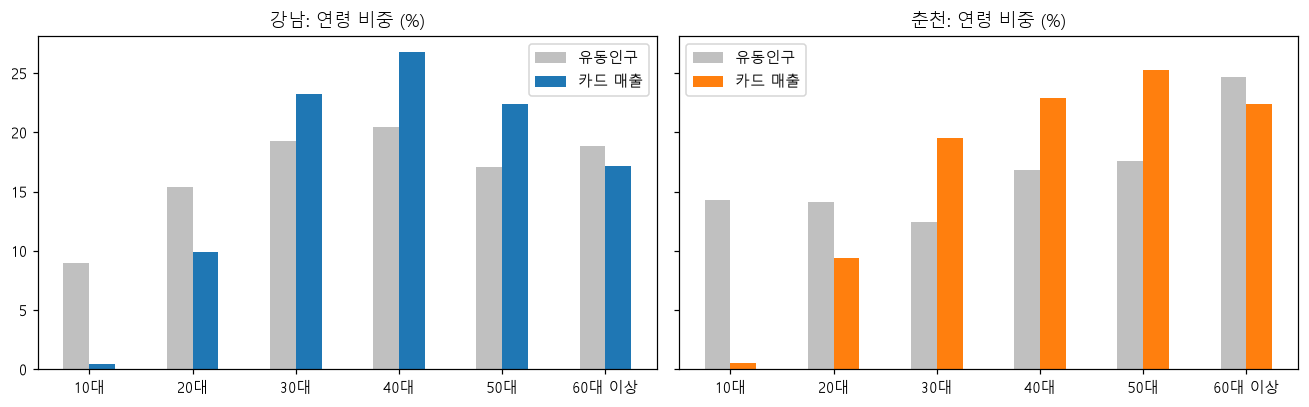

In [21]:
# 카드(base1) 연령 비중을 유동인구 연령 구간에 맞춰 비교
card_age = base1.pivot_table(index='region', columns='age', values='amount', aggfunc='sum')
card_age = card_age.div(card_age.sum(axis=1), axis=0) * 100
# 60대, 70대, 80대, 90대 -> 60대 이상 (유동인구 구간과 맞추기)
card_age = card_age.T.groupby(lambda a: '60대 이상' if a in ['60대', '70대', '80대', '90대'] else a).sum().T

flow_age_share = pyr.groupby(level=0).sum()                # 성별을 합침 -> 행 지역, 열 연령
age_cmp = pd.concat({'유동인구': flow_age_share[AGES], '카드': card_age[AGES]})
display(age_cmp.round(1))
ratio_age = card_age[AGES] / flow_age_share[AGES]            # 1보다 크면 돌아다니는 것에 비해 많이 쓰는 연령
display(ratio_age.round(2).rename_axis('카드 / 유동'))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, r in zip(axes, REGIONS):
    pd.DataFrame({'유동인구': flow_age_share.loc[r, AGES], '카드 매출': card_age.loc[r, AGES]}).plot(
        kind='bar', ax=ax, rot=0, color=['silver', REGION_COLOR[r]])
    ax.set(title=f'{r}: 연령 비중 (%)', xlabel='')
plt.tight_layout()
plt.show()

시사점: 10대는 유동인구의 9.0%(강남), 14.3%(춘천)인데 카드 매출은 0.5% 이하다. 반대로 30~50대는 매출 비중이 유동 비중의 1.2~1.6배다. 60대 이상은 두 지역 모두 0.91배로 유동과 매출이 비슷하다.

### 5장 정리
- **본 것**:
- **나온 것**:
- **시사점**:

## 6. 공간 분포 지도
사람이 **어디에** 모이는지 본다. SK 유동인구가 가장 잘하는 일이다.
지도는 한 달(예: 2025-10)만 쓰거나 6개월 평균을 쓴다. 값의 차이가 매우 크므로 색은 **로그 스케일**로 칠한다.

### 6-1. 격자 산점도 지도

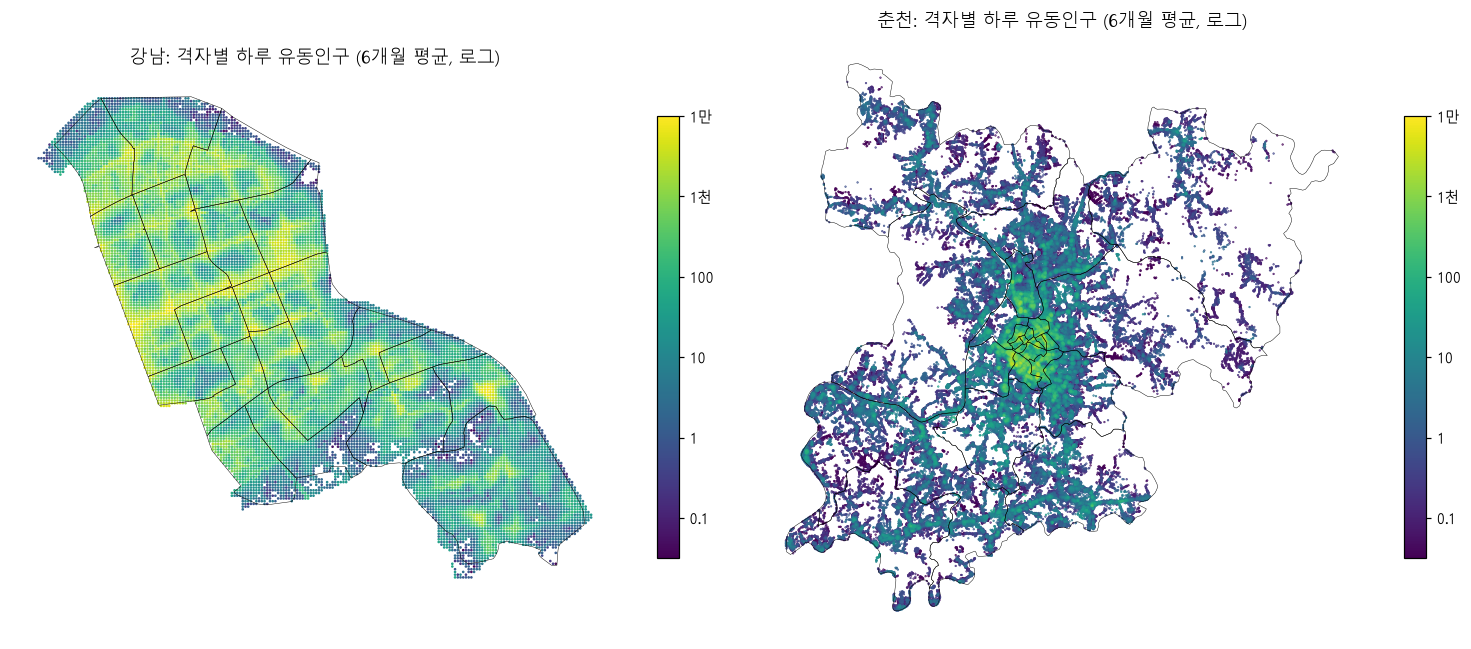

In [22]:
# 격자별 6개월 평균 유동인구 지도. 값 차이가 매우 커서 색은 log10(값)으로 칠함
grid = flow_age.groupby(['region', 'x', 'y'], as_index=False)['total'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, r in zip(axes, REGIONS):
    g = grid[grid['region'].eq(r)].sort_values('total')         # 큰 값이 위에 그려지게 작은 값부터
    sc = ax.scatter(g['x'], g['y'], c=np.log10(g['total']), s=0.5 if r == '강남' else 0.2, cmap='viridis',
                    vmin=-1.5, vmax=4)                          # 두 지도의 색 범위를 같게 (10^-1.5 ~ 10^4)
    dong5179[dong5179['region'].eq(r)].boundary.plot(ax=ax, color='k', lw=0.3)
    ax.set_aspect('equal')                                      # 가로 세로 비율을 같게
    ax.set_axis_off()
    ax.set_title(f'{r}: 격자별 하루 유동인구 (6개월 평균, 로그)')
    cb = fig.colorbar(sc, ax=ax, shrink=0.6)
    cb.set_ticks([-1, 0, 1, 2, 3, 4])
    cb.set_ticklabels(['0.1', '1', '10', '100', '1천', '1만'])  # log10 값을 원래 숫자로 표시
plt.tight_layout()
plt.show()

시사점: 강남은 구 전체가 격자로 빽빽이 덮여 있고, 테헤란로와 강남대로 쪽이 가장 밝다. 춘천은 넓은 땅 중 가운데 시가지에만 밝은 점이 몰려 있고, 외곽은 도로와 마을을 따라 가는 선처럼 흩어져 있다. <br>
춘천시의 가운데 시가지는 '시내동 지구'로 15개의 행정동으로 이뤄져있으며, 남춘천역, 춘천역, 버스터미널, 춘천대, 한림대, 도청, 명동 거리, 닭갈비 거리 등등이 있다.

### 6-2. 소수 격자 집중도

,격자 수,상위 1% 비중(%),상위 10% 비중(%)
강남,15383,12.60,56.40
춘천,85309,40.70,86.50


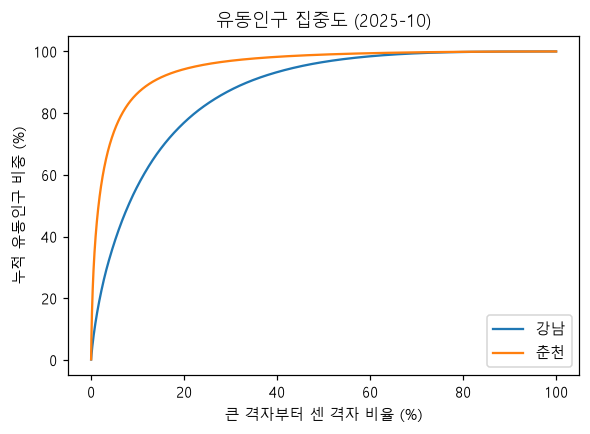

In [23]:
# 상위 1%, 10% 격자가 전체 유동인구의 몇 %를 차지하는가 (2025-10)
conc = {}
for r in REGIONS:
    s = a10.loc[a10['region'].eq(r), 'total'].sort_values(ascending=False)
    conc[r] = {'격자 수': len(s),
               '상위 1% 비중(%)': s.head(int(len(s) * 0.01)).sum() / s.sum() * 100,
               '상위 10% 비중(%)': s.head(int(len(s) * 0.10)).sum() / s.sum() * 100}
display(pd.DataFrame(conc).T.astype({'격자 수': int}).round(1))

# 누적 비중 곡선: x = 격자 순위 비율(큰 격자부터), y = 누적 비중
fig, ax = plt.subplots(figsize=(6, 4))
for r in REGIONS:
    s = a10.loc[a10['region'].eq(r), 'total'].sort_values(ascending=False)
    ax.plot(np.arange(1, len(s) + 1) / len(s) * 100, s.cumsum() / s.sum() * 100, color=REGION_COLOR[r], label=r)
ax.set(xlabel='큰 격자부터 센 격자 비율 (%)', ylabel='누적 유동인구 비중 (%)', title='유동인구 집중도 (2025-10)')
ax.legend()
plt.show()

시사점: 2025-10 기준 상위 1% 격자가 강남은 전체 유동인구의 12.6%, 춘천은 40.7%를 차지한다. 상위 10%는 강남 56.4%, 춘천 86.5%다.<br>춘천은 극히 일부 시가지에 사람이 몰려 있어서, 춘천의 날씨 효과는 사실상 시내 중심 상권의 반응이다. 강남은 구 전체에 비교적 고르게 퍼져 있다.

### 6-3. 행정동 단계구분도 (choropleth)

강남 상위 5: 역삼1동 16.8%, 삼성1동 8.1%, 대치2동 6.6%, 청담동 6.0%, 압구정동 5.9% / 하위: 개포1동 1.1%
춘천 상위 5: 퇴계동 15.8%, 강남동 12.1%, 석사동 10.0%, 신사우동 6.9%, 효자2동 4.9% / 하위: 북산면 0.2%


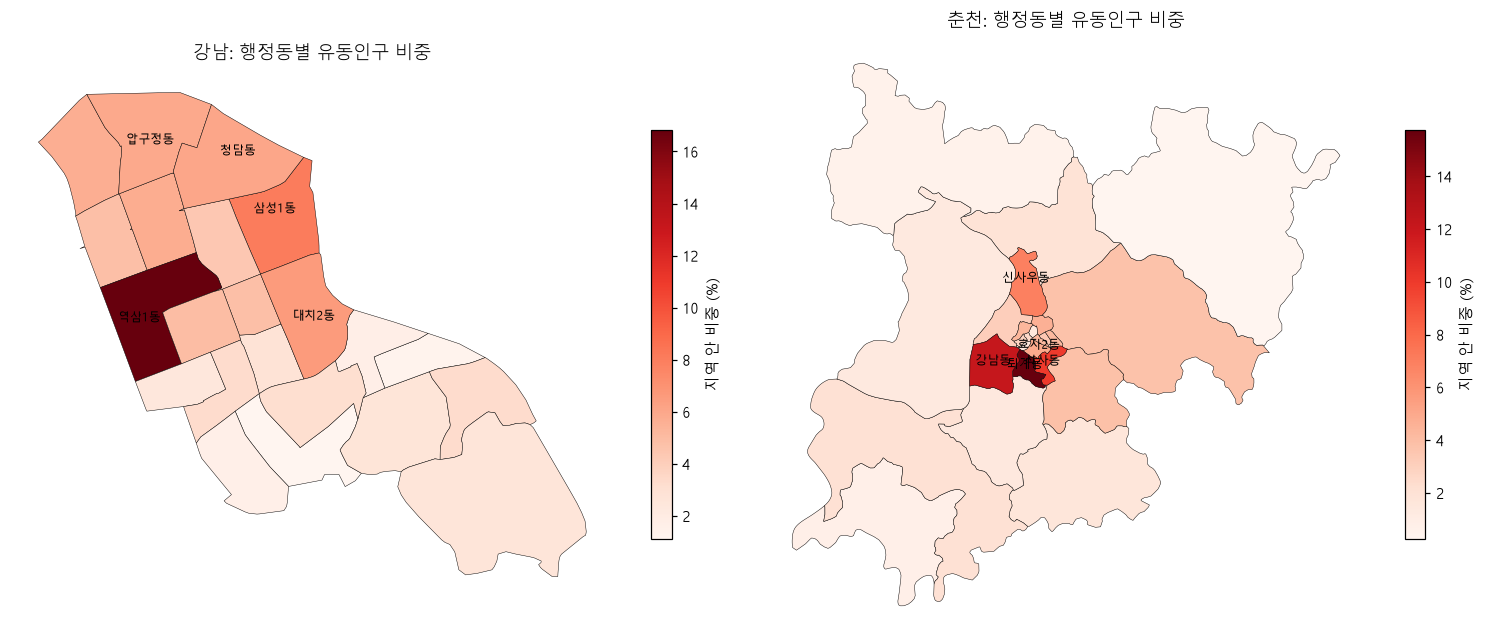

In [24]:
# 행정동별 월평균 유동인구 -> 지역 안 비중(%) -> 경계 지도에 색칠
by_dong = (flow_age.groupby('adm_cd')['total'].sum() / 6).rename('total').reset_index()
dmap = dong5179.merge(by_dong, on='adm_cd', how='left')        # 두 표의 adm_cd는 모두 글자 형식
dmap['share'] = dmap['total'] / dmap.groupby('region')['total'].transform('sum') * 100
# transform('sum'): 지역 합계를 원래 행 수 그대로 펼쳐 줌 -> 행마다 나눌 수 있음

for r in REGIONS:
    t = dmap[dmap['region'].eq(r)].sort_values('share', ascending=False)[['dong', 'share']]
    print(f"{r} 상위 5: {', '.join(f'{d} {v:.1f}%' for d, v in t.head(5).values)} / 하위: {t.iloc[-1, 0]} {t.iloc[-1, 1]:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
for ax, r in zip(axes, REGIONS):
    g = dmap[dmap['region'].eq(r)]
    g.plot(column='share', cmap='Reds', legend=True, edgecolor='k', lw=0.3, ax=ax,
           legend_kwds={'shrink': 0.6, 'label': '지역 안 비중 (%)'})
    for _, row in g.nlargest(5, 'share').iterrows():                  # 상위 5개 동에만 이름
        p = row.geometry.representative_point()                       # 도형 안에 반드시 들어가는 점
        ax.annotate(row['dong'], (p.x, p.y), fontsize=8, ha='center')
    ax.set_axis_off()
    ax.set_title(f'{r}: 행정동별 유동인구 비중')
plt.tight_layout()
plt.show()

시사점: 강남에서는 역삼1동(16.8%)이 유동인구가 가장 많고 삼성1동(8.1%), 대치2동(6.6%), 청담동(6.0%), 압구정동(5.9%) 순이며, 개포1동(1.1%)이 가장 적다. 춘천은 퇴계동(15.8%), 강남동(12.1%), 석사동(10.0%)의 세 동이 38%를 차지하고 북산면(0.2%)이 가장 적다.

### 6-4. 행정동별 주말 / 평일 비율 지도

강남 낮음: 역삼1동 0.56, 삼성2동 0.59, 논현2동 0.61 / 높음: 일원1동 1.00, 대치1동 1.02, 개포2동 1.08
춘천 낮음: 교동 0.58, 효자2동 0.70, 소양동 0.74 / 높음: 남산면 1.40, 남면 1.43, 서면 1.46


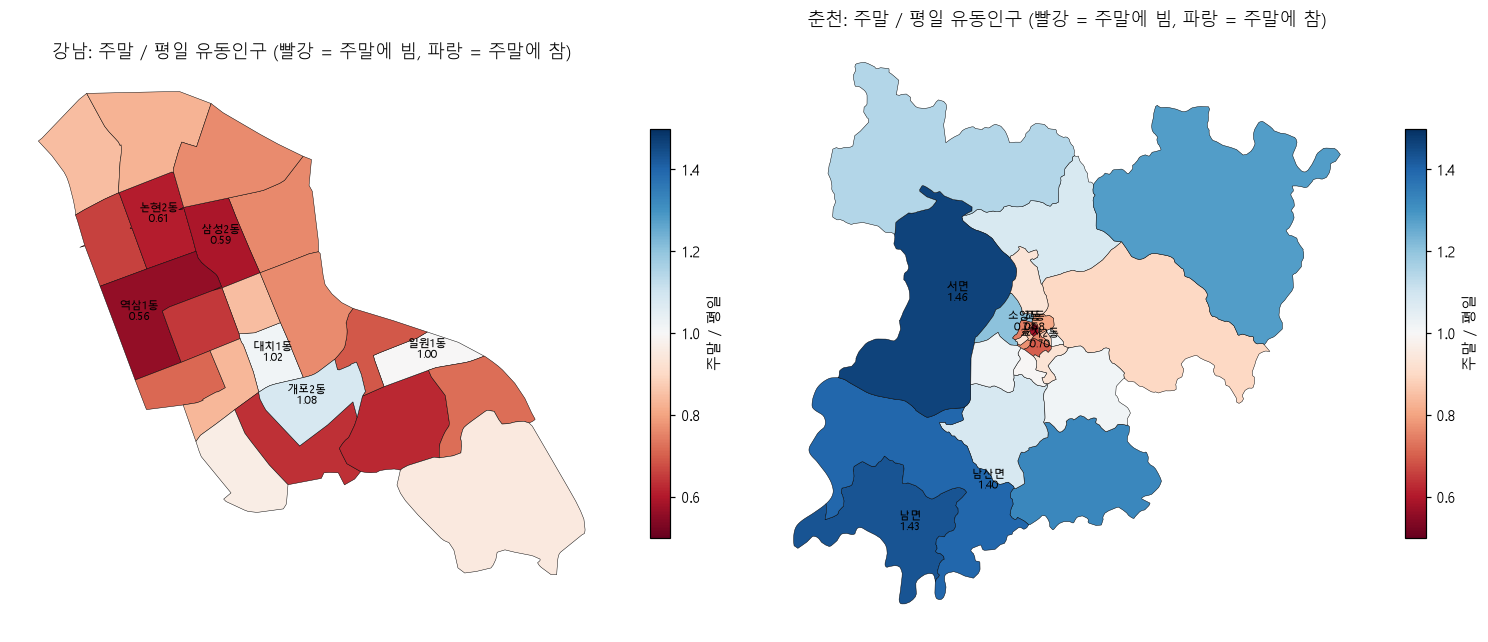

In [25]:
# 행정동별 주말 / 평일 비율 = (토, 일 평균) / (월~금 평균). 1보다 작으면 업무형, 크면 주거, 여가형
from matplotlib.colors import TwoSlopeNorm            # 색의 가운데를 원하는 값(1)에 두는 도구

dw = flow_wkdy.groupby('adm_cd')[WKDY_COLS].sum()
we_wd = (dw[WEEKEND_COLS].mean(axis=1) / dw[WEEKDAY_COLS].mean(axis=1)).rename('we_wd').reset_index()
dmap = dmap.merge(we_wd, on='adm_cd', how='left')

for r in REGIONS:
    t = dmap[dmap['region'].eq(r)].sort_values('we_wd')
    print(f"{r} 낮음: {', '.join(f'{d} {v:.2f}' for d, v in t[['dong', 'we_wd']].head(3).values)}"
          f" / 높음: {', '.join(f'{d} {v:.2f}' for d, v in t[['dong', 'we_wd']].tail(3).values)}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
for ax, r in zip(axes, REGIONS):
    g = dmap[dmap['region'].eq(r)]
    g.plot(column='we_wd', cmap='RdBu', norm=TwoSlopeNorm(vcenter=1, vmin=0.5, vmax=1.5),
           legend=True, edgecolor='k', lw=0.3, ax=ax, legend_kwds={'shrink': 0.6, 'label': '주말 / 평일'})
    for _, row in pd.concat([g.nsmallest(3, 'we_wd'), g.nlargest(3, 'we_wd')]).iterrows():
        p = row.geometry.representative_point()
        ax.annotate(f"{row['dong']}\n{row['we_wd']:.2f}", (p.x, p.y), fontsize=7, ha='center')
    ax.set_axis_off()
    ax.set_title(f'{r}: 주말 / 평일 유동인구 (빨강 = 주말에 빔, 파랑 = 주말에 참)')
plt.tight_layout()
plt.show()

시사점: 강남 역삼1동(0.56), 삼성2동(0.59), 논현2동(0.61)은 주말 유동이 평일의 60% 수준인 업무형이고, 개포2동(1.08), 대치1동(1.02)은 주말에도 줄지 않는 주거형이다.<br>춘천은 교동(0.58), 효자2동(0.70) 같은 시내가 주말에 비고, 서면(1.46), 남면(1.43), 남산면(1.40) 같은 외곽 면은 주말에 40% 넘게 늘어난다(강촌, 남이섬 방향 관광과 레저). 날씨 효과를 동 유형(업무형, 관광형)별로 나눠 해석할 때 쓸 수 있다.

**SK 유동인구의 한계 (꼭 기억할 것)**
- **월 단위 자료**이다. 값은 "그 달의 하루 평균"이라서 폭염일, 호우일 **하루**의 변화를 볼 수 없다. 7월과 8월 비교도 폭염 말고 휴가철, 추석 같은 다른 요인이 섞여 있다.
- 그래서 05번의 이벤트 분석(폭염 시작일 전후 궤적)에는 쓸 수 없다. 날짜별 사람 흐름은 **지하철(7~10장)** 로 본다.
- 이 자료가 잘하는 일은 **공간 구조**이다: 어느 동이 업무형인지 여가형인지(6-4), 사람이 몇 곳에 몰리는지(6-2), 시간대 모양(4-3).
- 값은 통신 기록으로 추정한 값이고, 아주 작은 값은 0으로 떨어지기도 한다(3장).

**결정**: SK 유동인구를 05번, 07번에서 더 쓸지 적어 둔다. (예: "이벤트 분석에는 안 쓴다. 결과 해석할 때 동 유형(6-4)과 시간대 모양(4-4)만 참고 자료로 쓴다")

- 결정:
- 이유:

### 6장 정리
- **본 것**:
- **나온 것**:
- **시사점**:

## 7. 지하철 역 목록 검토
지하철은 **날마다** 사람 흐름을 볼 수 있는 유일한 자료이다. 그 전에 어느 역을 "강남", "춘천"으로 볼지 확정한다.
기획 문서에는 "강남구 15개역, 춘천권 6개역"이라고 적혀 있지만, 01번은 강남 역 이름 27개(노선별로 32개), 춘천 5개를 표시했다.

### 7-1. 현재 표시된 역 확인

날짜수         첫날       마지막날  2025하반기(만)
region line     station                                         
강남     2호선      강남        1339 2023-01-01 2026-08-31    2,835.46
                삼성(무역센터)  1339 2023-01-01 2026-08-31    1,954.45
                선릉        1339 2023-01-01 2026-08-31    1,829.91
                역삼        1339 2023-01-01 2026-08-31    1,782.85
       3호선      대청        1339 2023-01-01 2026-08-31      369.87
                대치        1339 2023-01-01 2026-08-31      445.73
                도곡        1339 2023-01-01 2026-08-31      210.01
                매봉        1339 2023-01-01 2026-08-31      429.71
                수서        1339 2023-01-01 2026-08-31      667.63
                신사        1339 2023-01-01 2026-08-31      974.03
                압구정       1339 2023-01-01 2026-08-31    1,131.05
                일원        1339 2023-01-01 2026-08-31      381.85
                학여울       1339 2023-01-01 2026-08-31       91.82
       7호선      강남구청      1339 2023-01-01 2026-08-31      587.79
                논현        1339 2023-01-01 2026-08-31      662.17
                청담        1339 2023-01-01 2026-08-31      652.25
                학동        1339 2023-01-01 2026-08-31      776.16
       9호선      신논현       1339 2023-01-01 2026-08-31    1,140.99
       9호선2~3단계 봉은사       1339 2023-01-01 2026-08-31      849.52
                삼성중앙      1339 2023-01-01 2026-08-31      281.41
                선정릉       1339 2023-01-01 2026-08-31      362.12
                언주        1339 2023-01-01 2026-08-31      403.03
       분당선      강남구청      1339 2023-01-01 2026-08-31      349.17
                개포동       1339 2023-01-01 2026-08-31      157.76
                구룡        1339 2023-01-01 2026-08-31      122.94
                대모산입구     1339 2023-01-01 2026-08-31      199.05
                도곡        1339 2023-01-01 2026-08-31      265.11
                선릉        1339 2023-01-01 2026-08-31      537.08
                선정릉       1339 2023-01-01 2026-08-31      250.21
                수서        1339 2023-01-01 2026-08-31      636.58
                압구정로데오    1339 2023-01-01 2026-08-31      713.37
                한티        1339 2023-01-01 2026-08-31      578.34
춘천     경춘선      강촌        1339 2023-01-01 2026-08-31       18.04
                김유정       1339 2023-01-01 2026-08-31       16.14
                남춘천       1339 2023-01-01 2026-08-31      117.40
                백양리       1339 2023-01-01 2026-08-31        5.29
                춘천        1339 2023-01-01 2026-08-31       61.43

,노선별 역,역 이름
region,,
강남,32,27
춘천,5,5


전체 기간 날짜 수: 1339 / 184일 미만 또는 빠진 역: 0
강남 상위: 강남 12.5%, 선릉 10.5%, 삼성(무역센터) 8.6%, 역삼 7.9%, 수서 5.8%, 신논현 5.0%
춘천 상위: 남춘천 53.8%, 춘천 28.1%, 강촌 8.3%, 김유정 7.4%, 백양리 2.4%


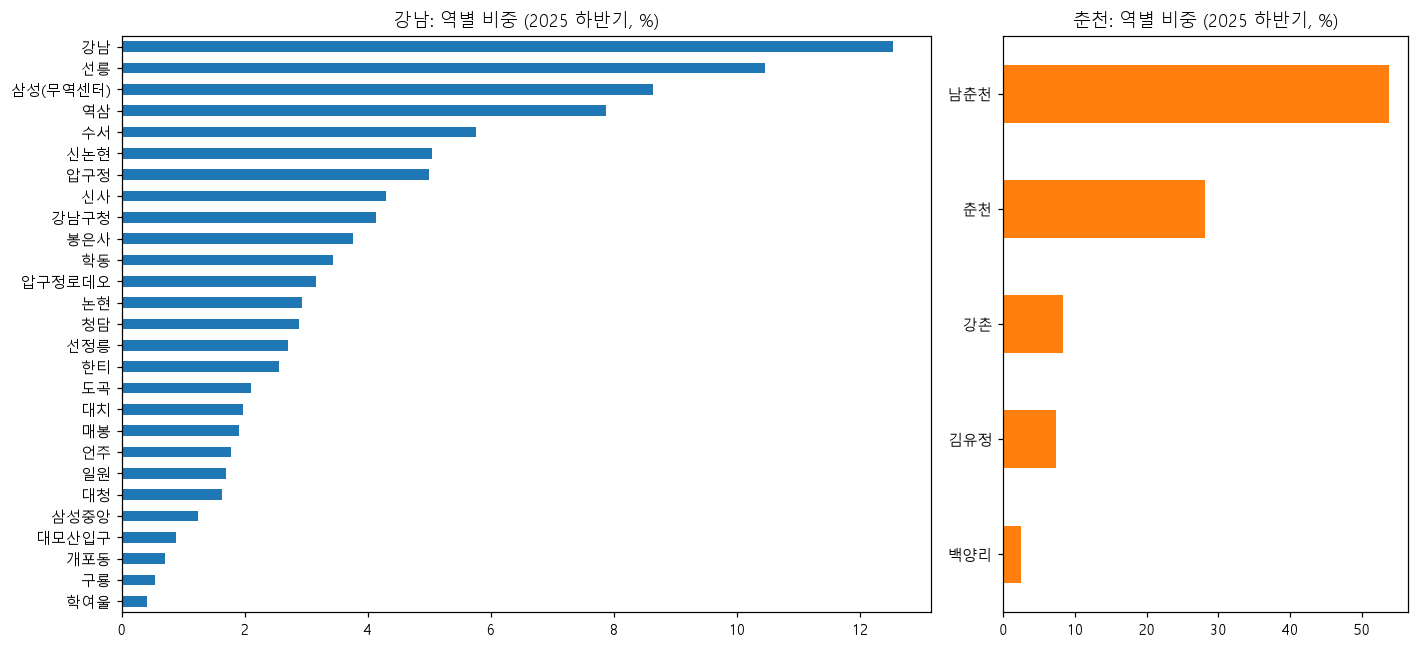

In [26]:
# 01번이 강남, 춘천으로 표시한 역 목록과 기간, 2025 하반기 이용객
tagged = subway[subway['region'].ne('기타')].assign(total=lambda d: d['board'] + d['alight'])
# assign(열=lambda d: ...): 새 열을 만들면서 표를 그대로 이어 씀
st = tagged.groupby(['region', 'line', 'station']).agg(
    날짜수=('date', 'nunique'), 첫날=('date', 'min'), 마지막날=('date', 'max'))
st['2025하반기(만)'] = (tagged[tagged['date'].between('2025-07-01', '2025-12-31')]
                        .groupby(['region', 'line', 'station'])['total'].sum() / 1e4)
display(st)

cnt = pd.DataFrame({'노선별 역': st.groupby(level='region').size(),                               # 환승역은 노선마다 한 줄
                    '역 이름': st.reset_index().groupby('region')['station'].nunique()})           # 이름 기준으로는 한 번만
display(cnt)
print('전체 기간 날짜 수:', subway['date'].nunique(), '/ 184일 미만 또는 빠진 역:', (st['날짜수'] < subway['date'].nunique()).sum())

# 2025 하반기 역 이름별 비중 (환승역은 노선 합침)
h2 = tagged[tagged['date'].between('2025-07-01', '2025-12-31')]
fig, axes = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={'width_ratios': [2, 1]})
for ax, r in zip(axes, REGIONS):
    s = h2[h2['region'].eq(r)].groupby('station')['total'].sum()
    s = (s / s.sum() * 100).sort_values()
    s.plot(kind='barh', ax=ax, color=REGION_COLOR[r])
    ax.set(title=f'{r}: 역별 비중 (2025 하반기, %)', ylabel='')
    print(f"{r} 상위: {', '.join(f'{k} {v:.1f}%' for k, v in s.sort_values(ascending=False).head(6).items())}")
plt.tight_layout()
plt.show()

시사점: 01번이 표시한 역은 강남 노선별 32개(역 이름 27개), 춘천 5개이고 모두 1,339일(2023-01-01 ~ 2026-08-31) 빠짐없이 있다. 기획 문서의 "강남구 15개역, 춘천권 6개역"과 다르다.<br>강남은 강남역 12.5%, 선릉 10.5%, 삼성(무역센터) 8.6%, 역삼 7.9% 순이고, 춘천은 남춘천(53.8%)과 춘천(28.1%) 두 역이 82%를 차지한다. 강촌(8.3%), 김유정(7.4%), 백양리(2.4%)는 관광형 역이다.

### 7-2. 빠진 역과 경계 역 확인

In [27]:
# 데이터에 있는 노선 이름 전체. 신분당선이 있는지 확인
lines = sorted(subway['line'].unique())
print(f'노선 {len(lines)}개:', ', '.join(lines))
print('신분당선 있음?', any('신분당' in l for l in lines))

# 경춘선 역 전체와 지역 표시
gc = subway[subway['line'].eq('경춘선')].drop_duplicates('station')[['station', 'region']]
print(f'경춘선 역 {len(gc)}개')
display(gc.set_index('station').T)

# 강남구 경계에 걸친 역들이 어떻게 표시됐는지
BORDER = ['교대', '양재', '고속터미널', '가락시장', '복정', '굴봉산', '가평']
display(subway[subway['station'].isin(BORDER)].drop_duplicates(['line', 'station'])[['line', 'station', 'region']]
        .sort_values('station').reset_index(drop=True))

노선 27개: 1호선, 2호선, 3호선, 4호선, 5호선, 6호선, 7호선, 8호선, 9호선, 9호선2~3단계, 경강선, 경부선, 경원선, 경의선, 경인선, 경춘선, 공항철도 1호선, 과천선, 분당선, 서해선, 수인선, 신림선, 안산선, 우이신설선, 일산선, 장항선, 중앙선
신분당선 있음? False


경춘선 역 19개


station,신내,갈매,별내,퇴계원,사릉,금곡,평내호평,천마산,마석,대성리,청평,상천,가평,굴봉산,백양리,강촌,김유정,남춘천,춘천
region,기타,기타,기타,기타,기타,기타,기타,기타,기타,기타,기타,기타,기타,기타,춘천,춘천,춘천,춘천,춘천


,line,station,region
0,3호선,가락시장,기타
1,8호선,가락시장,기타
2,경춘선,가평,기타
3,3호선,고속터미널,기타
4,7호선,고속터미널,기타
5,9호선,고속터미널,기타
6,경춘선,굴봉산,기타
7,8호선,복정,기타
8,분당선,복정,기타


시사점: 데이터의 노선 27개 중 수인분당선(==분당선)은 있는데, 신분당선이 없다. 그래서 신분당선 강남, 신논현, 논현, 신사역 이용객은 빠져 있고, 강남의 지하철 이용객은 실제보다 적게 잡힌다(한계로 적어둘 것).<br>경춘선 19개 역 중 춘천 5개 역만 표시돼 있고, 굴봉산과 가평은 '기타'다. 강남구 경계 밖인 고속터미널, 가락시장, 복정도 '기타'로 제대로 빠져 있다.

**결정**: 분석에 쓸 역 목록을 확정해야한다.

### 7장 정리
- **본 것**:
- **나온 것**:
- **시사점**:

## 8. 지하철 일별 추이와 달력 효과
지하철 자료는 2023-01 ~ 2026-08로 카드 데이터보다 훨씬 길다. 긴 흐름 속에서 2025년 하반기가 어떤 위치인지 보고,
요일과 연휴 효과의 크기를 잰다. 카드(02번 4장)와 비교하면 "사람 흐름"과 "소비"의 달력 효과가 어떻게 다른지 보인다.

### 8-1. 지역 일별 합계 표 만들기

In [28]:
# 강남, 춘천 역만 남겨서 날짜 × 지역별 승차, 하차 합계 -> 10-5에서 그대로 저장
subway_daily = (subway[subway['region'].ne('기타')]
                .groupby(['date', 'region'], as_index=False)[['board', 'alight']].sum())
# as_index=False: 묶은 열(date, region)을 행 이름이 아닌 보통 열로 남김
subway_daily['total'] = subway_daily['board'] + subway_daily['alight']
print(f'subway_daily: {len(subway_daily):,}행 ({subway_daily["date"].nunique():,}일 × {subway_daily["region"].nunique()}지역)')
display(subway_daily.head(2))

# 그래프용 넓은 표: 행 날짜, 열 강남, 춘천
sub_wide = subway_daily.pivot(index='date', columns='region', values='total')

ba = subway_daily.groupby('region')[['board', 'alight']].sum()
display((ba['board'] / ba['alight']).round(3).to_frame('승차 / 하차'))

subway_daily: 2,678행 (1,339일 × 2지역)


,date,region,board,alight,total
0,2023-01-01,강남,187280,183548,370828
1,2023-01-01,춘천,4758,4056,8814


,승차 / 하차
region,
강남,0.97
춘천,1.03


시사점: 강남, 춘천 역만 남겨 날짜 × 지역별로 합치면 정확히 2,678행(1,339일 × 2지역)이다. 승차 / 하차 비율은 강남 0.97로 내리는 사람이 조금 더 많고(밖에서 들어오는 통근과 방문), 춘천은 1.03이다.

### 8-2. 전체 기간 추이 (2023 ~ 2026)

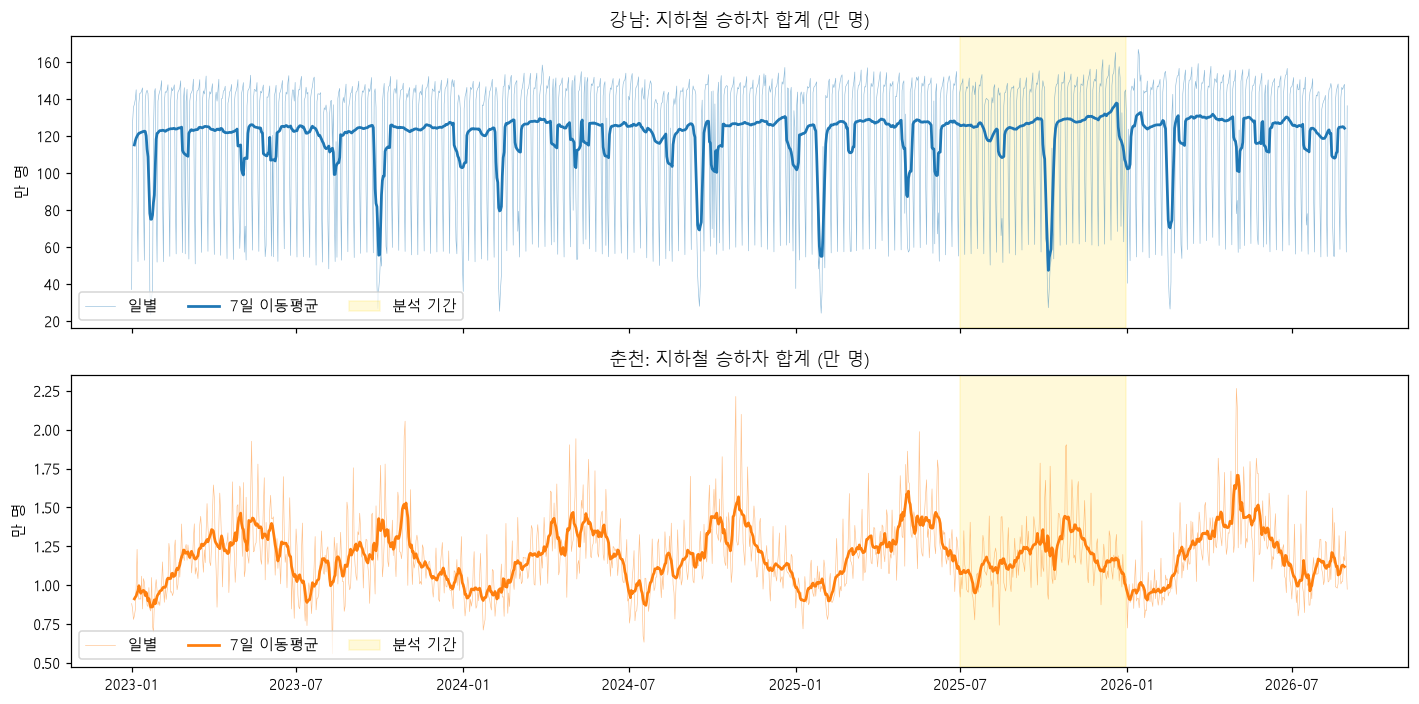

region,강남,춘천
연도,,
2023,118.62,1.17
2024,120.54,1.18
2025,121.38,1.20
2026,122.02,1.20


In [29]:
# 2023-01 ~ 2026-08 전체 추이. 얇은 선 = 일별, 굵은 선 = 7일 이동평균
fig, axes = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
for ax, r in zip(axes, REGIONS):
    y = sub_wide[r] / 1e4
    ax.plot(y.index, y, color=REGION_COLOR[r], lw=0.4, alpha=0.5, label='일별')
    ax.plot(y.index, y.rolling(7, center=True).mean(), color=REGION_COLOR[r], lw=1.8, label='7일 이동평균')
    ax.axvspan(pd.Timestamp('2025-07-01'), pd.Timestamp('2025-12-31'), color='gold', alpha=0.15, label='분석 기간')
    ax.set(title=f'{r}: 지하철 승하차 합계 (만 명)', ylabel='만 명')
    ax.legend(loc='lower left', ncol=3)
plt.tight_layout()
plt.show()

# 연도별 일평균 (2026은 1~8월)
display((sub_wide.groupby(sub_wide.index.year).mean() / 1e4).round(2).rename_axis('연도'))

시사점: 강남 지하철 일평균은 2023년 118.6만 명에서 2024년 120.5만, 2025년 121.4만, 2026년(1~8월) 122.0만 명으로 해마다 조금씩 늘고, 설과 추석마다 깊게 파인다. 춘천은 매해 약 1.2만 명으로 거의 일정하다.<br>강남은 장기적으로 늘어나는 추세가 있으므로 작년과 비교할 때 이 추세를 감안해야 한다.

### 8-3. 2025년 하반기 확대

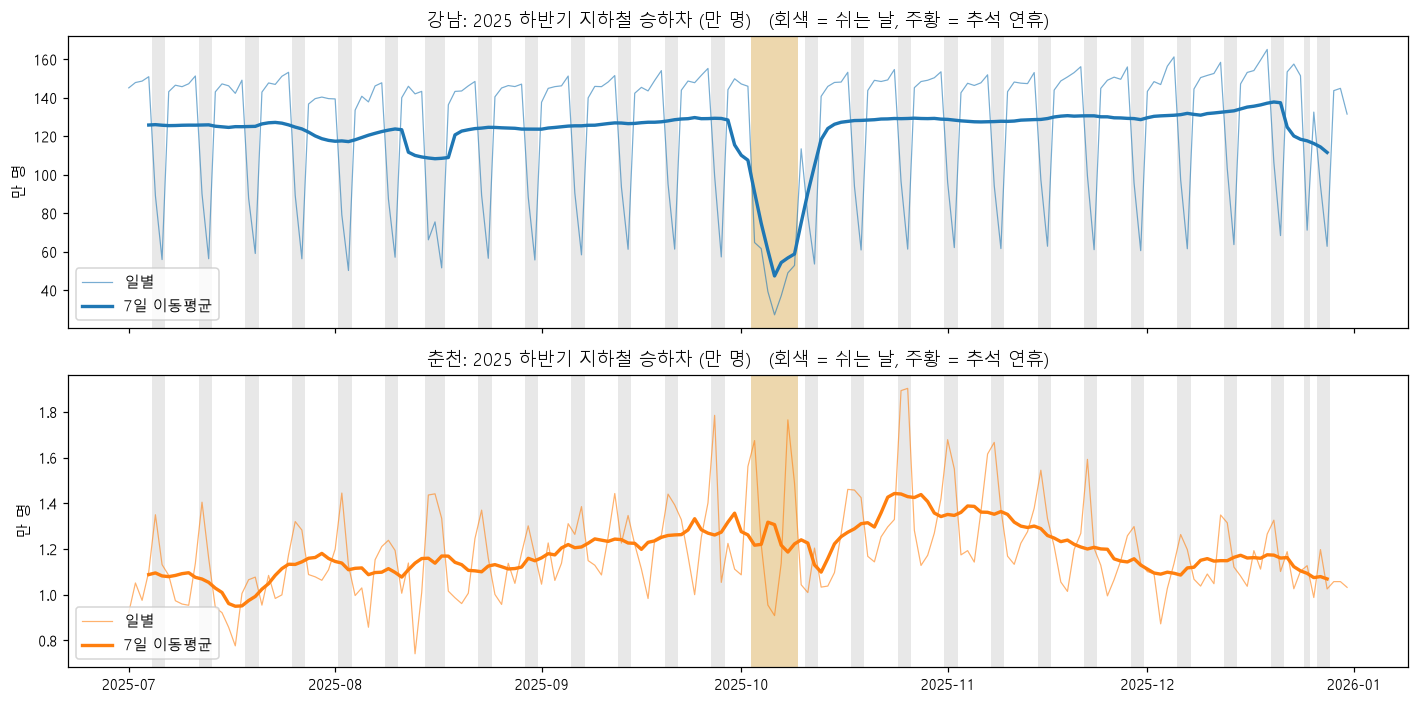

region,강남,춘천
mean,122.99,1.19
min,27.23,0.74
max,165.16,1.90


강남 최저 5일


,만 명,dow_name,holiday_name
date,,,
10/06,27.23,월,추석
10/07,37.10,화,추석 연휴
10/05,39.30,일,추석 연휴
10/08,49.05,수,대체공휴일(추석)
08/03,50.25,일,


강남 최고 5일


,만 명,dow_name,holiday_name
date,,,
12/19,165.16,금,
12/05,161.28,금,
12/18,159.59,목,
12/12,158.46,금,
12/23,157.56,화,


춘천 최저 5일


,만 명,dow_name,holiday_name
date,,,
08/13,0.74,수,
07/17,0.78,목,
07/16,0.86,수,
08/06,0.86,수,
12/03,0.87,수,


춘천 최고 5일


,만 명,dow_name,holiday_name
date,,,
10/26,1.90,일,
10/25,1.89,토,
09/27,1.78,토,
10/08,1.77,수,대체공휴일(추석)
11/01,1.68,토,


In [30]:
# 2025 하반기만 확대. 회색 = 쉬는 날, 주황 = 추석 연휴
sub25 = sub_wide.loc['2025-07-01':'2025-12-31']
fig, axes = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
for ax, r in zip(axes, REGIONS):
    shade_days(ax)
    y = sub25[r] / 1e4
    ax.plot(y.index, y, color=REGION_COLOR[r], lw=0.8, alpha=0.6, label='일별')
    ax.plot(y.index, y.rolling(7, center=True).mean(), color=REGION_COLOR[r], lw=2.2, label='7일 이동평균')
    ax.set(title=f'{r}: 2025 하반기 지하철 승하차 (만 명)   (회색 = 쉬는 날, 주황 = 추석 연휴)', ylabel='만 명')
    ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

display((sub25.agg(['mean', 'min', 'max']) / 1e4).round(2))
for r in REGIONS:
    for label, days in [('최저', sub25[r].nsmallest(5)), ('최고', sub25[r].nlargest(5))]:
        t = (days / 1e4).rename('만 명').to_frame().join(cal[['dow_name', 'holiday_name']])
        t.index = t.index.strftime('%m/%d')          # 날짜를 '10/06' 모양으로 짧게
        print(f'{r} {label} 5일')
        display(t.round(2))

시사점: 2025 하반기 일평균은 강남 약 123.0만 명(최소 27.2만, 최대 165.2만), 춘천 약 1.19만 명(최소 0.74만, 최대 1.90만)이다. 강남은 추석(10/6, 10/7, 10/5)에 가장 적고 12월 금요일에 가장 많다.<br>춘천은 가장 적은 날이 8/13, 7/17, 7/16으로 모두 평일이다. 02번에서 춘천 카드 매출도 7/17이 최저 5위였고 02번 정리에 이날 호우주의보가 발효됐다고 적혀 있으므로, 비 때문에 사람과 매출이 함께 줄어든 날일 가능성이 크다. 근데 강남도 7월 17일에 국지성 폭우가 내렸지만, 일별 승하차 추이를 보면 평소와 비슷하다.

### 8-4. 요일 패턴

월    화    수    목    금    토    일
지하철 강남 1.13 1.17 1.16 1.18 1.19 0.72 0.47
    춘천 0.94 0.91 0.88 0.97 1.07 1.18 1.06
카드  강남 1.03 1.07 1.02 1.04 1.12 1.03 0.69
    춘천 0.97 0.94 0.95 0.96 1.09 1.22 0.86

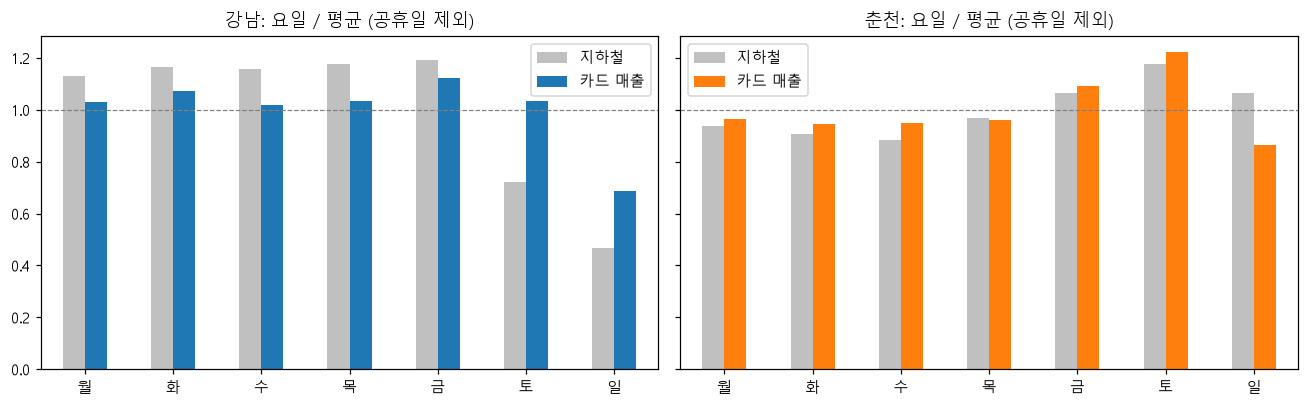

,주말 / 평일
station,
백양리,1.40
김유정,1.29
강촌,1.20
남춘천,1.16
춘천,1.16


In [31]:
# 공휴일 뺀 날로 요일별 평균 / 전체 평균. 카드와 나란히 비교
s25 = sub25.join(cal)                                           # 날짜 기준으로 달력 붙이기
nh = s25[~s25['is_holiday']]
sub_dow = nh.groupby('dow')[REGIONS].mean() / nh[REGIONS].mean()
sub_dow.index = DOW
display(pd.concat({'지하철': sub_dow.T, '카드': card_dow.T}).round(2))    # card_dow는 4-5에서 계산

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for ax, r in zip(axes, REGIONS):
    pd.DataFrame({'지하철': sub_dow[r], '카드 매출': card_dow[r]}).plot(kind='bar', ax=ax, rot=0,
                                                                     color=['silver', REGION_COLOR[r]])
    ax.axhline(1, ls='--', color='gray', lw=0.8)
    ax.set(title=f'{r}: 요일 / 평균 (공휴일 제외)', xlabel='')
plt.tight_layout()
plt.show()

# 춘천 역별 주말 / 평일 비율 (공휴일 제외)
cc = (h2[h2['region'].eq('춘천')].merge(calendar, on='date'))
cc = cc[~cc['is_holiday']].groupby(['station', 'is_weekend'])['total'].mean().unstack()
display((cc[True] / cc[False]).sort_values(ascending=False).round(2).to_frame('주말 / 평일'))

시사점: 강남 지하철은 평일 1.13~1.19, 토요일 0.72, 일요일 0.47로 전형적인 출퇴근형이다. 카드 매출은 토요일 1.03, 일요일 0.69로 지하철보다 훨씬 덜 빠진다. 강남에서 지하철은 "소비하러 온 사람"보다 "출근한 사람"을 주로 보여준다.<br>춘천은 지하철(금 1.07, 토 1.18)과 카드(금 1.09, 토 1.22)의 요일 모양이 비슷하다. 역별 주말 / 평일은 백양리 1.40, 김유정 1.29, 강촌 1.20으로 관광형 역일수록 주말에 더 늘어난다.

### 8-5. 공휴일과 추석 효과

공휴일 / 평일  추석 / 평일  주말 / 평일
    region                            
지하철 강남          0.35     0.32     0.51
    춘천          1.17     1.16     1.18
카드  강남          0.62     0.64     0.82
    춘천          1.06     1.11     1.07

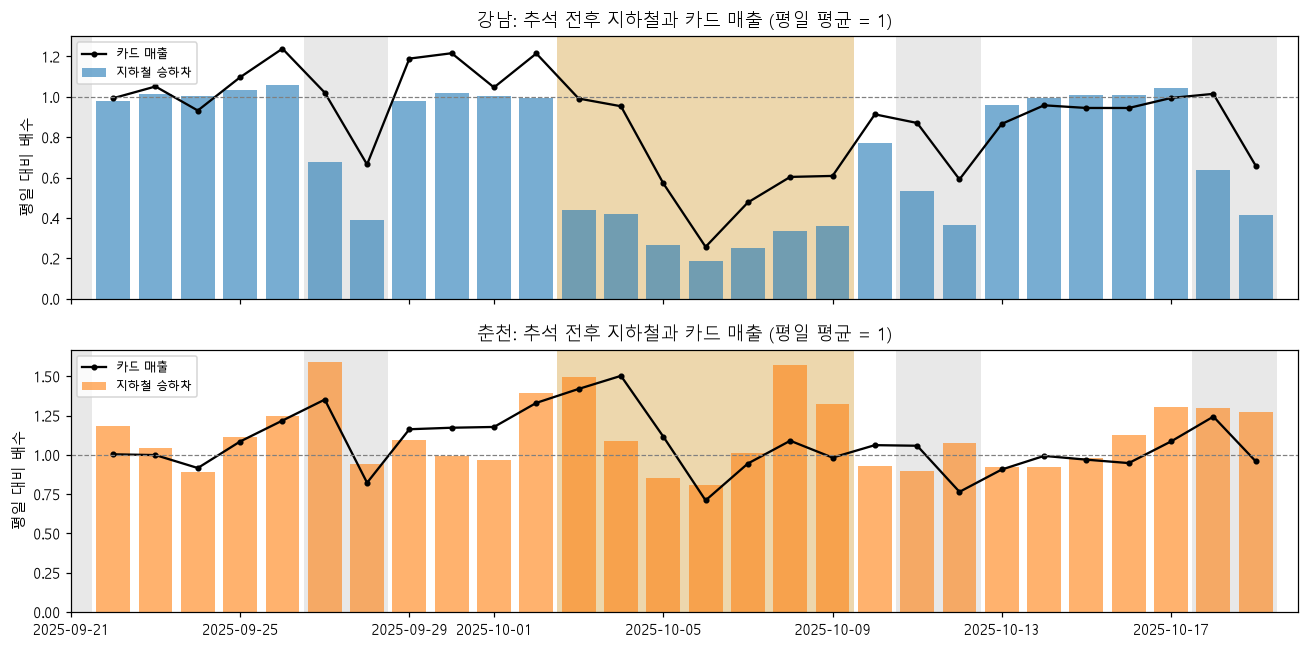

In [32]:
# 공휴일, 추석, 주말이 평일의 몇 배인지. 지하철과 카드를 한 표로
def calendar_ratio(df):
    """df: 행 날짜, 열 강남, 춘천. 평일 평균 대비 공휴일, 추석 연휴, 공휴일 아닌 주말 평균의 비율."""
    c = cal.reindex(df.index)
    wd = df[~c['is_offday']].mean()
    return pd.DataFrame({
        '공휴일 / 평일': df[c['is_holiday']].mean() / wd,
        '추석 / 평일': df[c['is_chuseok_break']].mean() / wd,
        '주말 / 평일': df[c['is_weekend'] & ~c['is_holiday']].mean() / wd,
    })


display(pd.concat({'지하철': calendar_ratio(sub25), '카드': calendar_ratio(sales)}).round(2))

# 추석 전후 3주: 지하철과 카드 매출을 같은 눈금(지역별 평일 평균 = 1)으로 겹쳐 그리기
# 단위가 다른 두 자료(만 명, 억 원)를 "평일의 몇 배인가"로 바꾸면 한 그래프에서 비교할 수 있음
off = cal['is_offday'].reindex(sub25.index)
sub_rel = sub25 / sub25[~off].mean()              # 지하철: 그날 / 2025 하반기 평일 평균
card_rel = sales / sales[~off.reindex(sales.index)].mean()   # 카드 매출도 같은 방식

win = slice('2025-09-22', '2025-10-19')
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, r in zip(axes, REGIONS):
    shade_days(ax)
    s = sub_rel.loc[win, r]
    k = card_rel.loc[win, r]
    ax.bar(s.index, s, color=REGION_COLOR[r], width=0.8, alpha=0.6, label='지하철 승하차')
    ax.plot(k.index, k, color='black', marker='o', ms=3, lw=1.5, label='카드 매출')
    ax.axhline(1, ls='--', color='gray', lw=0.8)              # 1 = 평일 평균
    ax.set(title=f'{r}: 추석 전후 지하철과 카드 매출 (평일 평균 = 1)', ylabel='평일 대비 배수')
    ax.legend(loc='upper left', fontsize=8)
ax.set_xlim(s.index.min() - pd.Timedelta(days=1), s.index.max() + pd.Timedelta(days=1))
plt.tight_layout()
plt.show()

시사점: 강남 지하철은 공휴일에 평일의 0.35배, 추석에 0.32배, 주말에 0.51배로 줄지만 카드 매출은 0.62배, 0.64배, 0.82배로 덜 줄어든다. 춘천은 지하철(1.16~1.18배)과 카드(1.06~1.11배) 모두 쉬는 날에 늘어난다.<br>연휴 효과가 지하철에서 훨씬 크기 때문에, 지하철과 매출의 관계를 볼 때 연휴를 포함하면 "달력 효과끼리의 상관"이 섞인다(10장).<br>추석 전후 그래프(평일 평균 = 1)를 보면, 강남 지하철은 연휴 7일 내내 평일의 0.2~0.45배로 떨어져 있지만, 카드 매출은 연휴 첫 이틀(10/3, 10/4)에 평일 수준을 유지하다가 추석 당일(10/6)에 0.26배로 가장 낮고 연휴 끝 무렵 0.6배로 돌아온다. 사람 흐름이 빠진 만큼 매출이 줄지는 않는다.<br>춘천은 연휴 직전(10/2~10/4)에 지하철과 카드가 함께 평일의 1.3~1.5배로 높고, 추석 당일에 함께 0.7~0.8배로 낮아진다. 10/8에는 지하철만 1.57배로 튀는데, 연휴 끝 귀경 이동으로 보인다.

### 8장 정리
- **본 것**:
- **나온 것**:
- **시사점**:

## 9. 작년 같은 기간과 비교
2025년 하반기는 폭염이 길었다. 지하철 이용이 **작년(2024년 하반기)보다 줄었는지** 보면, 날씨 때문에 사람 흐름이 줄었을 가능성을 대략 가늠할 수 있다.
주의: 추석 날짜가 해마다 달라서(2024년 9/16~9/18, 2025년 10/5~10/7) 단순 월별 비교는 추석에 오염된다.

### 9-1. 하반기 전체 일평균 비교

In [33]:
# 해마다 7/1 ~ 12/31 일평균 비교
h2_mean = pd.DataFrame({y: sub_wide.loc[f'{y}-07-01':f'{y}-12-31'].mean() for y in [2023, 2024, 2025]}).T / 1e4
display(h2_mean.round(2).rename_axis('하반기 일평균(만 명)'))
growth = pd.DataFrame({'2024 대 2023 (%)': (h2_mean.loc[2024] / h2_mean.loc[2023] - 1) * 100,
                       '2025 대 2024 (%)': (h2_mean.loc[2025] / h2_mean.loc[2024] - 1) * 100})
display(growth.round(2))

region,강남,춘천
하반기 일평균(만 명),,
2023,118.33,1.16
2024,120.51,1.19
2025,122.99,1.19


,2024 대 2023 (%),2025 대 2024 (%)
region,,
강남,1.84,2.06
춘천,2.54,0.05


시사점: 하반기 일평균은 강남이 2023년 118.3만, 2024년 120.5만, 2025년 123.0만 명으로 2025년이 작년보다 2.1% 많다. 춘천은 2024년과 2025년 모두 1.19만 명(+0.05%)으로 같다.<br>폭염이 길었던 2025년 하반기에도 지하철 이용이 하반기 전체로는 줄지 않았다.

### 9-2. 월별 전년 대비 (YoY)

region,강남,춘천
date,,
2025-07,1.00,10.00
2025-08,-0.20,0.70
2025-09,15.70,1.10
2025-10,-8.10,-6.50
2025-11,-0.90,-2.80
2025-12,6.30,1.10


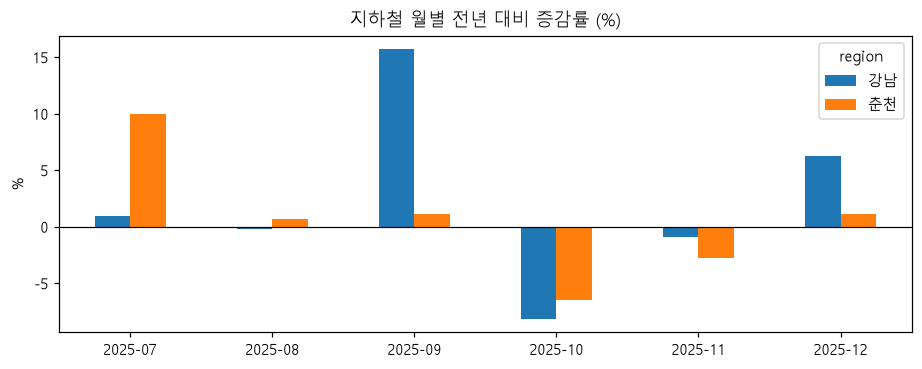

In [34]:
# 월별 일평균 -> 12개월 전 같은 달과 비교 (YoY)
m = sub_wide.resample('MS').mean()
yoy = (m / m.shift(12) - 1) * 100            # shift(12): 12행(= 12개월) 아래로 밀기 -> 같은 행에 작년 같은 달 값
yoy25 = yoy.loc['2025-07':'2025-12']
yoy25.index = yoy25.index.strftime('%Y-%m')
display(yoy25.round(1))

ax = yoy25.plot(kind='bar', rot=0, color=[REGION_COLOR[r] for r in REGIONS], figsize=(10, 3.5))
ax.axhline(0, color='k', lw=0.8)
ax.set(title='지하철 월별 전년 대비 증감률 (%)', xlabel='', ylabel='%')
plt.show()

시사점: 월별 전년 대비 증감률은 강남 9월 +15.7%, 10월 -8.1%, 춘천 10월 -6.5%처럼 9~10월에 크게 흔들린다. 2024년 추석은 9월(9/16~9/18), 2025년 추석은 10월(10/5~10/7)이라 생긴 차이로, 날씨 효과로 읽으면 안 된다.<br>폭염이 가장 심했던 7~8월은 강남 +1.0%, -0.2%, 춘천 +10.0%, +0.7%로 작년과 비슷하거나 더 많다.

### 9-3. 요일 맞춘 비교 (364일 전, 공휴일 제외)

비교에 남은 날: 168일


,비율 평균 - 1 (%),합계 비율 - 1 (%)
region,,
강남,2.00,1.70
춘천,1.80,0.30


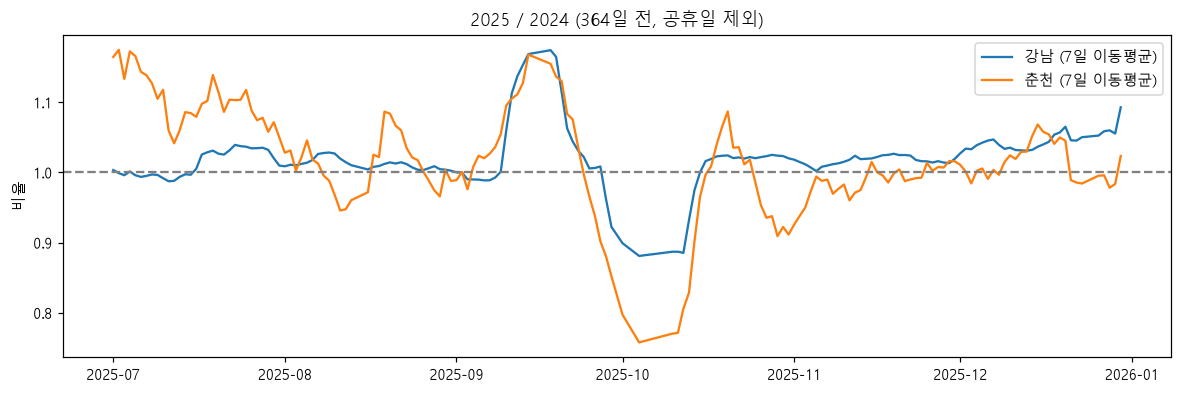

In [35]:
# 364일 전 = 정확히 52주 전 -> 요일이 같음. 두 해 모두 공휴일이 아닌 날만 비교
lag = sub_wide.shift(364)                        # 364행 아래로 밀기 (날짜가 빠짐없이 이어져 있어서 가능)
ratio = (sub_wide / lag).loc['2025-07-01':'2025-12-31']

HOL_2024 = pd.to_datetime(['2024-08-15', '2024-09-16', '2024-09-17', '2024-09-18',
                           '2024-10-01', '2024-10-03', '2024-10-09', '2024-12-25',
                           '2025-01-01'])   # 2025-12-31의 364일 전 = 2025-01-01(신정)이라 이것도 빼야 함
ok = (~cal['is_holiday'].reindex(ratio.index).values
      & ~(ratio.index - pd.Timedelta(days=364)).isin(HOL_2024))          # 두 해 중 한쪽이라도 공휴일이면 뺌
print(f'비교에 남은 날: {ok.sum()}일')

s_now = sub_wide.loc[ratio.index[ok]]
s_prev = lag.loc[ratio.index[ok]]
display(pd.DataFrame({'비율 평균 - 1 (%)': (ratio[ok].mean() - 1) * 100,
                      '합계 비율 - 1 (%)': (s_now.sum() / s_prev.sum() - 1) * 100}).round(1))

fig, ax = plt.subplots(figsize=(13, 3.8))
for r in REGIONS:
    ax.plot(ratio.index[ok], ratio.loc[ok, r].rolling(7, center=True, min_periods=4).mean(),
            color=REGION_COLOR[r], label=f'{r} (7일 이동평균)')
ax.axhline(1, ls='--', color='gray')
ax.set(title='2025 / 2024 (364일 전, 공휴일 제외)', ylabel='비율')
ax.legend()
plt.show()

시사점: 요일을 맞추고(364일 전) 두 해의 공휴일을 뺀 168일로 비교하면, 날마다의 비율 평균은 강남 +2.0%, 춘천 +1.8%, 합계 기준으로는 강남 +1.7%, 춘천 +0.3%다. (처음에는 2025-12-31의 비교 대상인 2025-01-01 신정을 빼지 않아 강남이 +3.5%로 부풀었는데, 신정을 제외 목록에 넣어 고쳤다.)<br>9월 중순에 두 지역이 함께 1.17배로 오르고 10월 초에 0.8~0.9배로 내려가는 건 추석이 2024년 9월에서 2025년 10월로 옮겨가서 생긴 것이다(공휴일 당일은 뺐지만 연휴 앞뒤 날의 영향은 남음).<br>하반기 전체 수준에서는 폭염 때문에 지하철 이용이 줄었다는 흔적이 보이지 않는다. 날씨 효과가 있다면 특정 날짜에 짧게 나타날 것이므로 05번에서 날짜 단위로 봐야 한다.

### 9장 정리
- **본 것**:
- **나온 것**:
- **시사점**:

## 10. 지하철과 카드 매출은 같이 움직이나
날씨가 나쁜 날 매출이 줄었다면, **사람이 안 나와서**인지 **나왔지만 덜 써서**인지 구분해야 한다.
여기서는 날씨 없이, 두 지표가 평소에 얼마나 같이 움직이는지만 본다. 두 지표 모두 요일 효과가 크기 때문에 **요일을 걷어낸 뒤에도** 같이 움직이는지가 핵심이다.

### 10-1. 날마다 상관 (원자료)

,total,board,alight
카드와의 상관,,,
강남,0.73,0.73,0.74
춘천,0.57,0.55,0.55


공휴일 빼면 (total): {'강남': 0.69, '춘천': 0.57}
강남: 지하철이 1만 명 많을 때 카드 매출 → 평일 +2.73억 원, 쉬는 날 +5.28억 원
춘천: 지하철이 1만 명 많을 때 카드 매출 → 평일 +31.92억 원, 쉬는 날 +36.83억 원


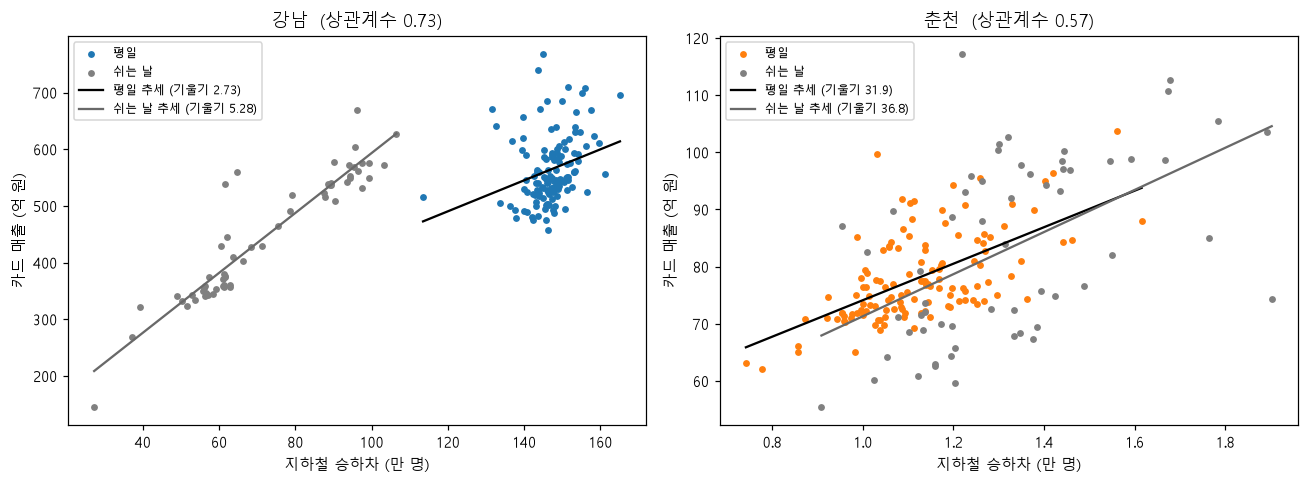

In [36]:
# 2025 하반기 지하철(승차, 하차, 합계)과 카드 일매출을 날짜로 붙여 상관 보기
s25b = subway_daily[subway_daily['date'].between('2025-07-01', '2025-12-31')]
corr_raw = pd.DataFrame({
    met: {r: s25b[s25b['region'].eq(r)].set_index('date')[met].corr(sales[r]) for r in REGIONS}
    for met in ['total', 'board', 'alight']})
display(corr_raw.round(2).rename_axis('카드와의 상관'))

hol = cal['is_holiday'].reindex(sales.index)
print('공휴일 빼면 (total):', {r: round(sub25.loc[~hol.values, r].corr(sales.loc[~hol, r]), 2) for r in REGIONS})

def add_trend(ax, x, y, color, label):
    """산점도 위에 직선 추세선을 긋고, 기울기를 범례에 적는다.
    np.polyfit(x, y, 1): 점들을 가장 잘 지나는 직선 y = 기울기 × x + 절편 을 찾음 (1 = 1차식, 즉 직선)"""
    slope, intercept = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 50)                       # 선을 그릴 x 위치 50개
    ax.plot(xs, slope * xs + intercept, color=color, lw=1.5, label=f'{label} 추세 (기울기 {slope:.3g})')
    return slope

off = cal['is_offday'].reindex(sales.index)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, r in zip(axes, REGIONS):
    ax.scatter(sub25.loc[~off.values, r] / 1e4, sales.loc[~off, r], s=12, color=REGION_COLOR[r], label='평일')
    ax.scatter(sub25.loc[off.values, r] / 1e4, sales.loc[off, r], s=12, color='gray', label='쉬는 날')
    # 추세선: 평일과 쉬는 날을 따로 (쉬는 날은 두 값이 함께 떨어져 있어서, 섞으면 선이 가팔라짐)
    s_wd = add_trend(ax, sub25.loc[~off.values, r] / 1e4, sales.loc[~off, r], 'black', '평일')
    s_off = add_trend(ax, sub25.loc[off.values, r] / 1e4, sales.loc[off, r], 'dimgray', '쉬는 날')
    print(f'{r}: 지하철이 1만 명 많을 때 카드 매출 → 평일 {s_wd:+.2f}억 원, 쉬는 날 {s_off:+.2f}억 원')
    ax.set(title=f'{r}  (상관계수 {corr_raw.loc[r, "total"]:.2f})', xlabel='지하철 승하차 (만 명)', ylabel='카드 매출 (억 원)')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

시사점: 2025 하반기 지하철 승하차와 카드 일매출의 상관은 강남 0.73, 춘천 0.57이고, 승차, 하차, 합계 사이에 차이가 거의 없다. 공휴일을 빼도 강남 0.69, 춘천 0.57이다.<br>상관이 꽤 높지만, 두 지표가 모두 요일과 연휴를 따라 움직이기 때문일 수 있다. 산점도에서도 쉬는 날(회색)과 평일이 따로 뭉쳐 있다.

### 10-2. 요일을 걷어낸 뒤의 상관

,전체 184일,공휴일 제외,추석 연휴 제외
요일 보정 후 상관,,,
강남,0.67,0.34,0.45
춘천,0.47,0.50,0.52


,지하철,카드
요일 보정 값 표준편차,,
강남,0.06,0.10
춘천,0.12,0.08


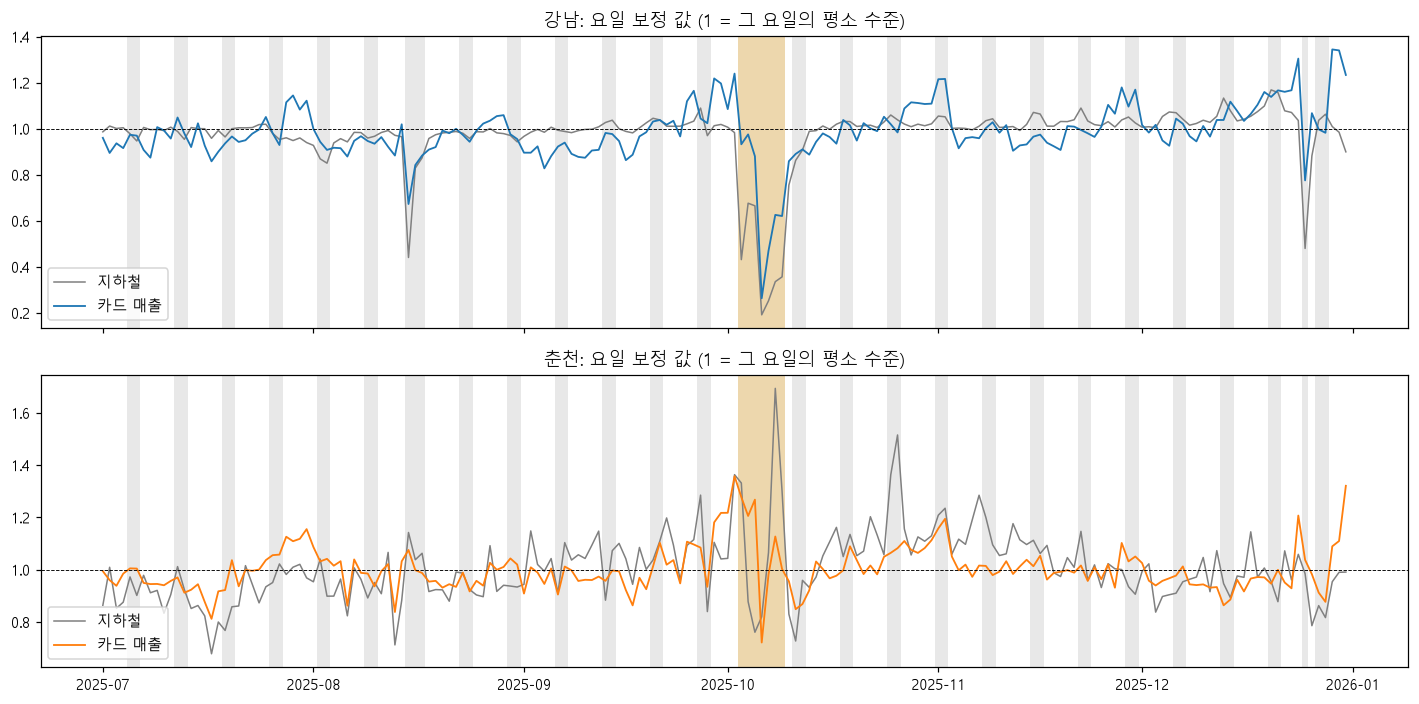

In [37]:
# 요일 보정 값 = 그날 값 / 같은 요일 평균 (평균은 공휴일 빼고 계산). 02번 4-3과 같은 방법
def dow_adjust(df):
    """df: 행 날짜, 열 강남, 춘천. 같은 요일 평균(공휴일 제외)으로 나눈 값을 돌려준다."""
    c = cal.reindex(df.index)
    mean_dow = df[~c['is_holiday']].groupby(c.loc[~c['is_holiday'], 'dow']).mean()   # 요일(0~6)별 평균
    return df / mean_dow.reindex(c['dow']).values            # 날짜마다 그 요일의 평균을 꺼내 나눔


sub_adj = dow_adjust(sub25)
sal_adj = dow_adjust(sales)
c = cal.reindex(sales.index)
corr_adj = pd.DataFrame({
    '전체 184일': {r: sub_adj[r].corr(sal_adj[r]) for r in REGIONS},
    '공휴일 제외': {r: sub_adj.loc[~c['is_holiday'], r].corr(sal_adj.loc[~c['is_holiday'], r]) for r in REGIONS},
    '추석 연휴 제외': {r: sub_adj.loc[~c['is_chuseok_break'], r].corr(sal_adj.loc[~c['is_chuseok_break'], r]) for r in REGIONS},
})
display(corr_adj.round(2).rename_axis('요일 보정 후 상관'))
display(pd.DataFrame({'지하철': sub_adj[~c['is_holiday']].std(), '카드': sal_adj[~c['is_holiday']].std()})
        .round(3).rename_axis('요일 보정 값 표준편차'))

fig, axes = plt.subplots(2, 1, figsize=(13, 6.5), sharex=True)
for ax, r in zip(axes, REGIONS):
    shade_days(ax)
    ax.plot(sub_adj.index, sub_adj[r], color='gray', lw=1, label='지하철')
    ax.plot(sal_adj.index, sal_adj[r], color=REGION_COLOR[r], lw=1.2, label='카드 매출')
    ax.axhline(1, ls='--', color='k', lw=0.6)
    ax.set(title=f'{r}: 요일 보정 값 (1 = 그 요일의 평소 수준)')
    ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

시사점: 요일 효과를 걷어내면 강남의 상관은 전체 184일 0.67에서 공휴일 제외 0.34, 추석 제외 0.45로 크게 떨어진다. 강남의 높은 상관은 연휴에 둘 다 푹 꺼졌기 때문이고, 평범한 날에는 지하철이 그대로여도 매출이 따로 움직이는 날이 많다.<br>춘천은 공휴일 제외 0.50, 추석 제외 0.52로 유지된다. 춘천은 사람이 줄면 매출도 함께 주는 편이라 지하철이 매출의 좋은 보조 지표다. 요일 보정 값의 흔들림(표준편차)은 강남 지하철 0.06, 카드 0.10으로 강남은 매출이 사람보다 더 흔들린다.

### 10-3. 둘 다 빠진 날, 매출만 빠진 날

강남: 지하철이 가장 낮은 6일


,지하철,카드,dow_name
date,,,
10/04,0.68,0.97,토
10/10,0.75,0.86,금
08/16,0.83,0.84,토
08/03,0.85,0.91,일
10/11,0.86,0.89,토
08/02,0.87,0.94,토


강남: 카드가 가장 낮은 6일


,지하철,카드,dow_name
date,,,
09/04,0.98,0.83,목
08/16,0.83,0.84,토
07/17,0.96,0.86,목
10/10,0.75,0.86,금
09/16,0.99,0.86,화
09/10,1.00,0.87,수


춘천: 지하철이 가장 낮은 6일


,지하철,카드,dow_name
date,,,
07/17,0.68,0.81,목
08/13,0.71,0.84,수
10/11,0.73,0.85,토
07/19,0.77,0.92,토
12/26,0.79,0.98,금
07/18,0.80,0.92,금


춘천: 카드가 가장 낮은 6일


,지하철,카드,dow_name
date,,,
07/17,0.68,0.81,목
08/13,0.71,0.84,수
10/11,0.73,0.85,토
08/06,0.82,0.86,수
09/17,0.94,0.86,수
12/13,0.95,0.86,토


강남: 지하철이 평소보다 10% 많을 때 카드 매출은 평소보다 +5.8%
춘천: 지하철이 평소보다 10% 많을 때 카드 매출은 평소보다 +3.3%


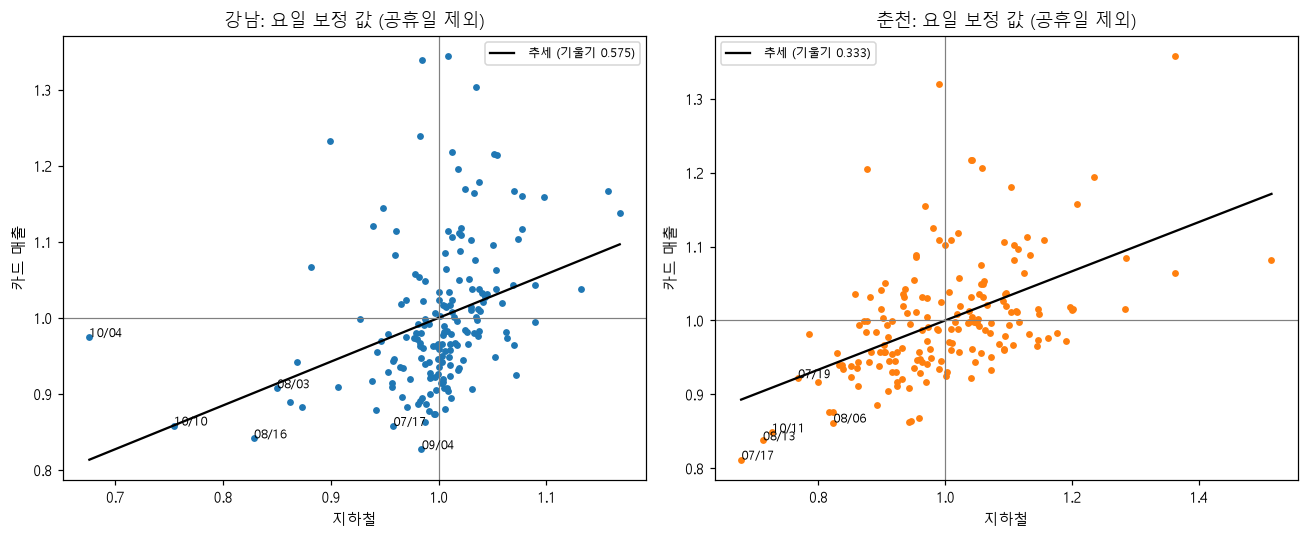

In [38]:
# 공휴일 뺀 날 중에서 "둘 다 빠진 날"과 "매출만 빠진 날" 찾기
nh_idx = sales.index[~c['is_holiday']]
for r in REGIONS:
    t = pd.DataFrame({'지하철': sub_adj.loc[nh_idx, r], '카드': sal_adj.loc[nh_idx, r]})
    t = t.join(cal['dow_name'])
    for label, key in [('지하철이 가장 낮은 6일', '지하철'), ('카드가 가장 낮은 6일', '카드')]:
        s = t.nsmallest(6, key)
        s.index = s.index.strftime('%m/%d')
        print(f'{r}: {label}')
        display(s.round(2))

# 산점도 + 네 칸 기준선: 왼쪽 아래 = 둘 다 빠짐, 오른쪽 아래 = 매출만 빠짐
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, r in zip(axes, REGIONS):
    x, y = sub_adj.loc[nh_idx, r], sal_adj.loc[nh_idx, r]
    ax.scatter(x, y, s=12, color=REGION_COLOR[r])
    slope = add_trend(ax, x, y, 'black', '')                  # 10-1에서 만든 함수. 공휴일을 이미 뺐으니 선 하나
    print(f'{r}: 지하철이 평소보다 10% 많을 때 카드 매출은 평소보다 {slope * 10:+.1f}%')
    ax.legend(fontsize=8)
    ax.axvline(1, color='gray', lw=0.8)
    ax.axhline(1, color='gray', lw=0.8)
    low = (x.rank() <= 4) | (y.rank() <= 4)                  # 둘 중 하나라도 가장 낮은 4일 안에 드는 날에 라벨
    for d in x.index[low]:
        ax.annotate(d.strftime('%m/%d'), (x[d], y[d]), fontsize=8)
    ax.set(title=f'{r}: 요일 보정 값 (공휴일 제외)', xlabel='지하철', ylabel='카드 매출')
plt.tight_layout()
plt.show()

시사점: 춘천은 7/17(지하철 0.68, 카드 0.81), 8/13(0.71, 0.84), 10/11(0.73, 0.85)에 사람과 매출이 함께 빠졌다. 탐색 Q6-b의 "유동↓ 매출↓" 형이고, 호우일 후보다.<br>강남은 매출이 가장 낮은 9/4(지하철 0.98, 카드 0.83)에 지하철은 평소 수준이었다. "유동 유지, 매출만↓" 형이다. 반대로 강남 10/4(0.68, 0.97)는 연휴 중 토요일이라 사람은 빠졌는데 매출은 그대로였다. 이 날들의 날씨를 04번에서 확인하고 07번 Q6-b로 넘긴다.

### 10-4. 승차, 하차, 합계 중 무엇을 쓸까

In [39]:
# 승차, 하차, 합계 중 어느 지표가 매출과 가장 잘 맞는지 (요일 보정, 공휴일 제외)
res = {}
for met in ['board', 'alight', 'total']:
    wide = s25b.pivot(index='date', columns='region', values=met)
    adj = dow_adjust(wide)
    res[met] = {r: adj.loc[~c['is_holiday'].values, r].corr(sal_adj.loc[~c['is_holiday'], r]) for r in REGIONS}
display(pd.DataFrame(res).round(3).rename_axis('카드와의 상관'))

# 승차 / 하차 비율의 요일 패턴 (공휴일 제외)
ba = s25b.pivot(index='date', columns='region', values='board') / s25b.pivot(index='date', columns='region', values='alight')
ba_dow = ba[~c['is_holiday'].values].groupby(cal['dow'].reindex(ba.index)[~c['is_holiday'].values]).mean()
ba_dow.index = DOW
display(ba_dow.T.round(3).rename_axis('승차 / 하차'))

,board,alight,total
카드와의 상관,,,
강남,0.33,0.34,0.34
춘천,0.46,0.50,0.49


,월,화,수,목,금,토,일
승차 / 하차,,,,,,,
강남,0.97,0.97,0.97,0.97,0.97,0.98,1.00
춘천,0.96,1.03,1.03,1.12,1.11,1.01,1.00


시사점: 요일 보정 후 카드와의 상관은 강남이 승차 0.33, 하차 0.34, 합계 0.34, 춘천이 승차 0.46, 하차 0.50, 합계 0.49로 세 지표의 차이가 작다. 강남은 승차 / 하차 비율이 요일과 관계없이 0.97~1.00으로 거의 일정하다.<br>하루 단위 분석에는 승하차 합계(total) 하나면 충분하다.

### 10-5. 05번, 07번에 넘길 표 저장

In [40]:
# 8-1의 subway_daily를 약속한 열 순서로 저장 (기간 전체 2023-01-01 ~ 2026-08-31)
subway_region_daily = subway_daily[['date', 'region', 'board', 'alight', 'total']]
subway_region_daily.to_parquet(OUT / 'subway_region_daily.parquet', index=False)

check = pd.read_parquet(OUT / 'subway_region_daily.parquet')          # 다시 읽어서 확인
print(f'저장: subway_region_daily.parquet  {len(check):,}행 × {check.shape[1]}열  {list(check.columns)}')
print('1,339일 × 2지역 =', 1339 * 2, '| 2025 하반기 행 수:', check['date'].between('2025-07-01', '2025-12-31').sum())
display(check.dtypes.to_frame('dtype'))

저장: subway_region_daily.parquet  2,678행 × 5열  ['date', 'region', 'board', 'alight', 'total']
1,339일 × 2지역 = 2678 | 2025 하반기 행 수: 368


,dtype
date,datetime64[ns]
region,object
board,int64
alight,int64
total,int64


**결정**: 05번, 07번에서 쓸 지하철 지표를 적어 둔다. (예: "total. 요일 보정 값으로 비교. 강남은 연휴 제외 상관이 약하므로 보조 지표로만")

- 결정:
- 이유:

### 10장 정리
- **본 것**:
- **나온 것**:
- **시사점**:

## 11. 전체 정리

### 11-1. 다음 노트북으로 넘길 결정 사항
그래프를 모두 본 뒤 채운다. 05번(기상 × 카드)과 07번(탐색 Q1~Q9)에서 이 목록을 그대로 가져다 쓴다.

| 항목 | 결정 | 근거 (몇 장) |
|---|---|---|
| 지하철 역 목록 (강남, 춘천) | | 7장 |
| 신분당선 누락 처리 (한계로 적기 등) | | 7-2 |
| 지하철 지표 (total / board / alight) | | 10-4 |
| 지하철과 매출 비교 방법 (요일 보정 값, 연휴 제외 여부) | | 10-2 |
| Q6-b에서 먼저 볼 날짜 (둘 다 빠진 날, 매출만 빠진 날) | | 10-3, 8-3 |
| SK 유동인구를 이후에 쓸지, 쓴다면 어디에 | | 6장 한계 |
| 유동인구 행정동 코드 (adm_cd 그대로 쓰기 여부) | | 2장 |
| 주말 0 격자 처리 | | 3-4 |
| 동 유형(업무형, 여가형) 구분을 해석에 쓸지 | | 6-4 |

### 11-2. 더 확인할 것
04번, 05번, 07번에서 확인할 질문을 적어 둔다.
- 예: 춘천 7/16, 7/17, 8/13은 평일인데 지하철이 최저 -> 04번에서 그날 강수량 확인 (호우?)
- 예: 강남 9/4는 지하철은 평소 수준인데 매출만 크게 낮음 -> 날씨? 다른 이유?
- 예: 강남은 오후(12~17시)에 매출이 사람 수보다 더 몰림(4-4) -> 낮 폭염이 매출을 비율 이상으로 줄이는지 05번에서
-